# Trabajo Práctico: Predicción de precios de casas

Aprendizaje Automático 1 · Tecnicatura Universitaria en Inteligencia Artificial (FCEIA, UNR) · Segundo cuatrimestre 2026

Integrantes: Civetta, Valentino; Frank, Maximiliano; Fucci, Milagros; Winter, Federico.

Objetivo: predecir `MEDV`, el valor mediano de las viviendas en miles de dólares, con regresión lineal múltiple, descenso del gradiente y modelos regularizados.

Requiere `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn` y `catboost`. El dataset se lee desde `./data/house-prices-tp.csv`.

## Índice

Trabajo grupal de cuatro integrantes. El texto del notebook usa la primera persona del plural porque lo resolvimos entre todos.

1. Carga e inspección del dataset
   - Nulos por columna, por fila y limpieza de filas
   - Columnas numéricas y distribuciones
   - Codificación de variables categóricas
   - Tests de normalidad, outliers con IQR y matrices de correlación
2. Conclusiones de la matriz de correlación
3. Coherencia de los outliers (`CRIM`, `ZN` y `B`)
4. Separación en train y test, e imputación con `KNNImputer`
5. Método del codo para elegir `n_neighbors`
6. Imputación final con `KNNImputer`
7. Imputación de `RAD` y `CHAS` con `CatBoostClassifier`
8. Distribuciones antes y después de imputar
9. Resumen del preprocesamiento
10. Modelado
    - Regresión lineal con scikit-learn
    - Descenso del gradiente (batch, estocástico y mini-batch)
    - Comparación de los métodos
    - Regularización: Ridge, Lasso y ElasticNet
11. Optimización de hiperparámetros
12. Comparación de modelos
13. Conclusión

Las funciones del descenso del gradiente provienen del material de la cátedra.

In [1]:
# Librerías y configuración de gráficos y tablas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='tab10')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.5
numpy: 2.5.3


## Carga e inspección del dataset

556 registros y 14 variables. Es un problema de **regresión**: predecir `MEDV` (continua) a partir de las otras 13.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `CRIM` | Continua | Tasa de criminalidad per cápita por municipio |
| `ZN` | Continua | Proporción de suelo residencial zonificado para lotes de más de 25.000 pies cuadrados |
| `INDUS` | Continua | Proporción de acres comerciales no minoristas por municipio |
| `CHAS` | Categórica | Variable ficticia del río Charles (1 si limita con el río; 0 en caso contrario) |
| `NOX` | Continua | Concentración de óxidos nítricos (indicador de contaminación del aire) |
| `RM` | Continua | Cantidad promedio de habitaciones por vivienda |
| `AGE` | Continua | Proporción de viviendas antiguas (construidas antes de 1940) ocupadas por sus dueños |
| `DIS` | Continua | Distancias ponderadas a cinco grandes centros de empleo |
| `RAD` | Discreta | Índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | Tasa de impuesto a la propiedad por cada $10.000 |
| `PTRATIO` | Continua | Proporción de alumnos por maestro en la zona |
| `B` | Continua | Índice matemático relacionado a la proporción de población afroamericana |
| `LSTAT` | Continua | Porcentaje de la población considerada de bajo estatus socioeconómico |
| `MEDV` | Continua | **Variable objetivo:** Valor mediano de las viviendas en miles de dólares ($1000s) |

In [2]:
# Cargamos el dataset
df_casas=pd.read_csv('./data/house-prices-tp.csv')

In [3]:
# Vista rápida de los datos
df_casas

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,0.0824,30.0000,4.9300,0.0000,0.4280,6.4810,18.5000,6.1899,6.0000,300.0000,16.6000,379.4100,6.3600,23.7000
552,0.4755,0.0000,9.9000,0.0000,0.5440,6.1130,58.8000,4.0019,4.0000,304.0000,18.4000,396.2300,12.7300,21.0000
553,0.2498,0.0000,21.8900,0.0000,0.6240,5.8570,98.2000,1.6686,4.0000,437.0000,21.2000,392.0400,21.3200,13.3000
554,32.5040,6.5286,8.9373,1.0000,NaN,4.0166,NaN,5.2438,20.4169,197.2366,19.6391,6.2671,7.0340,23.0288


In [4]:
# Tipo de dato y cantidad de valores no nulos por columna
df_casas.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [5]:
# Estadísticas descriptivas de cada variable
df_casas.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.0000,534.0000,541.0000,533.0000,532.0000,535.0000,532.0000,541.0000,528.0000,538.0000,528.0000,534.0000,534.0000,535.0000
mean,5.8455,13.1972,11.2187,0.0901,0.5600,6.2918,67.6323,3.9441,9.6994,409.5751,18.4299,347.8060,13.0281,22.7468
std,13.8286,24.9030,6.9420,0.2865,0.1195,0.7824,28.4619,2.2557,8.6845,167.6894,2.1948,99.6362,7.5800,9.4915
min,0.0063,0.0000,0.4600,0.0000,0.3850,3.5610,2.9000,1.1296,1.0000,187.0000,12.6000,0.3200,1.7300,5.0000
25%,0.0845,0.0000,5.1300,0.0000,0.4530,5.8755,42.2750,2.1121,4.0000,279.0000,17.0000,369.5300,7.1500,16.7500
50%,0.3153,0.0000,9.6900,0.0000,0.5380,6.2080,76.5000,3.3401,5.0000,335.0000,19.0000,390.8150,11.4650,21.2000
75%,4.8714,20.0000,18.1000,0.0000,0.6440,6.6385,93.8250,5.4007,23.6327,666.0000,20.2000,395.8900,17.2050,26.3000
max,88.9762,100.0000,27.7400,1.0000,0.8710,8.7800,100.0000,12.1265,24.0000,711.0000,22.0000,396.9000,37.9700,50.0000


### Nulos por columna

In [6]:
# Cantidad y porcentaje de nulos por columna
nulos = df_casas.isnull().sum()
pct_nulos = (nulos / len(df_casas)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23          4.1367  float64
ZN          22          3.9568  float64
INDUS       15          2.6978  float64
CHAS        23          4.1367  float64
NOX         24          4.3165  float64
RM          21          3.7770  float64
AGE         24          4.3165  float64
DIS         15          2.6978  float64
RAD         28          5.0360  float64
TAX         18          3.2374  float64
PTRATIO     28          5.0360  float64
B           22          3.9568  float64
LSTAT       22          3.9568  float64
MEDV        21          3.7770  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


`MEDV`, el target, tiene 21 nulos. Eliminamos esas filas: imputar el target sería inventar las respuestas que el modelo tiene que aprender.

In [7]:
# Valores que toma RAD: aparecen decimales que no son ninguna categoría
df_casas['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 , 19.26689099,  3.05654826, 23.51021334, 17.11018134,
       18.17750289,  2.40242419,  4.52856858,  2.57361455, 22.32831295,
       14.19552773, 20.41690761])

In [8]:
# Sacamos las filas sin target
df_casas_limpio = df_casas.dropna(subset=['MEDV'])

In [9]:
# RAD después de sacar las filas sin MEDV
df_casas_limpio['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 ,  3.05654826, 17.11018134,  2.40242419,  2.57361455,
       14.19552773, 20.41690761])

In [10]:
# Redondeamos RAD y marcamos como NaN lo que no cae en una categoría válida; se imputa más adelante con CatBoost
df_casas_limpio['RAD'] = df_casas_limpio['RAD'].round()
valores_validos_rad = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 24.0]

df_casas_limpio.loc[~df_casas_limpio['RAD'].isin(valores_validos_rad), 'RAD'] = np.nan

In [11]:
# Nulos por columna después de limpiar MEDV y RAD
nulos = df_casas_limpio.isnull().sum()
pct_nulos = (nulos / len(df_casas_limpio)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas_limpio.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas_limpio.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        11          2.0561  float64
ZN          11          2.0561  float64
INDUS        4          0.7477  float64
CHAS         9          1.6822  float64
NOX          9          1.6822  float64
RM           7          1.3084  float64
AGE         11          2.0561  float64
DIS          5          0.9346  float64
RAD         23          4.2991  float64
TAX          9          1.6822  float64
PTRATIO      9          1.6822  float64
B            9          1.6822  float64
LSTAT        9          1.6822  float64
MEDV         0          0.0000  float64

Total de celdas con nulos: 126 (1.6822% del dataset)


Al sacar las filas sin `MEDV`, el total de celdas nulas baja de 3.93 % a 1.68 %. En casi todas las columnas los nulos bajan a la mitad o cerca. `RAD` baja menos (de 5.04 % a 4.30 %) porque ahora sus valores inválidos también cuentan como nulos.

### Filas con algún nulo

In [12]:
# Filas con al menos un nulo
df_nulos = df_casas_limpio[df_casas_limpio.isnull().any(axis=1)]
df_nulos

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
14,30.9865,60.7115,8.8272,0.0000,0.7476,NaN,23.5934,5.0625,NaN,621.3307,16.6349,60.1620,30.4948,23.6754
23,73.6057,90.4347,12.7403,0.0000,NaN,8.0501,22.5424,5.7312,NaN,NaN,21.2916,NaN,NaN,28.1301
66,NaN,57.3495,3.0478,1.0000,0.8139,4.3715,42.0051,NaN,NaN,260.0063,16.8671,95.2918,NaN,30.0891
88,NaN,51.4067,NaN,NaN,NaN,NaN,8.0227,NaN,NaN,NaN,18.3460,NaN,NaN,35.8650
128,NaN,NaN,13.6140,1.0000,0.6554,6.9344,26.1907,10.5900,7.0000,433.5793,12.7216,81.8895,NaN,12.9376
158,NaN,16.0260,NaN,0.0000,0.8158,7.6807,16.3767,10.7724,NaN,NaN,NaN,99.9282,NaN,49.0005
172,48.3319,12.3063,25.4002,1.0000,0.7618,NaN,77.5480,10.3482,NaN,NaN,15.5791,219.0445,29.7366,14.4423
203,2.0876,NaN,3.7731,NaN,NaN,NaN,72.4877,1.8957,NaN,592.6382,15.3468,NaN,36.2203,45.2828
223,NaN,NaN,15.5236,NaN,NaN,NaN,35.5404,1.9678,1.0000,NaN,13.3648,200.6252,NaN,40.6947
230,23.7853,67.3783,21.0065,0.0000,0.8591,8.4211,70.7801,5.8163,NaN,NaN,20.1837,370.9914,9.3324,24.2417


### Nulos por fila

Cuántas filas tienen 0, 1, 2 o más nulos, para fijar un umbral de descarte.

In [13]:
# Cantidad de filas según cuántos nulos tienen (sobre 14 columnas)
df_casas_limpio.isnull().sum(axis=1).value_counts().sort_index()

0     506
1       2
2       4
3       9
4       4
5       1
6       2
7       3
8       2
9       1
10      1
Name: count, dtype: int64

### Descartamos las filas con más de la mitad de faltantes

In [14]:
# Nos quedamos con las filas que tienen al menos la mitad de los valores (7 de 14)
df_casas_limpio = df_casas_limpio.dropna(thresh=len(df_casas_limpio.columns)*0.5)
df_casas_limpio.info()

<class 'pandas.DataFrame'>
Index: 531 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     524 non-null    float64
 1   ZN       521 non-null    float64
 2   INDUS    530 non-null    float64
 3   CHAS     525 non-null    float64
 4   NOX      525 non-null    float64
 5   RM       526 non-null    float64
 6   AGE      523 non-null    float64
 7   DIS      529 non-null    float64
 8   RAD      512 non-null    float64
 9   TAX      523 non-null    float64
 10  PTRATIO  524 non-null    float64
 11  B        525 non-null    float64
 12  LSTAT    525 non-null    float64
 13  MEDV     531 non-null    float64
dtypes: float64(14)
memory usage: 62.2 KB


Se eliminan 4 filas y quedan 531. Según la tabla de nulos por fila, 506 de las 535 filas están completas y 25 tienen entre 1 y 7 nulos. Las 4 filas que salen tienen 8 o más nulos sobre 14: tendrían más valores imputados que medidos.

### Columnas numéricas

Excluimos CHAS (categorica) y RAD (discreta ordinal) del análisis de distribuciones y outliers.

In [15]:
# Variables continuas; CHAS y RAD son categóricas y se tratan aparte
columnas_numericas = [col for col in df_casas_limpio.columns if col != 'CHAS' and col != 'RAD']


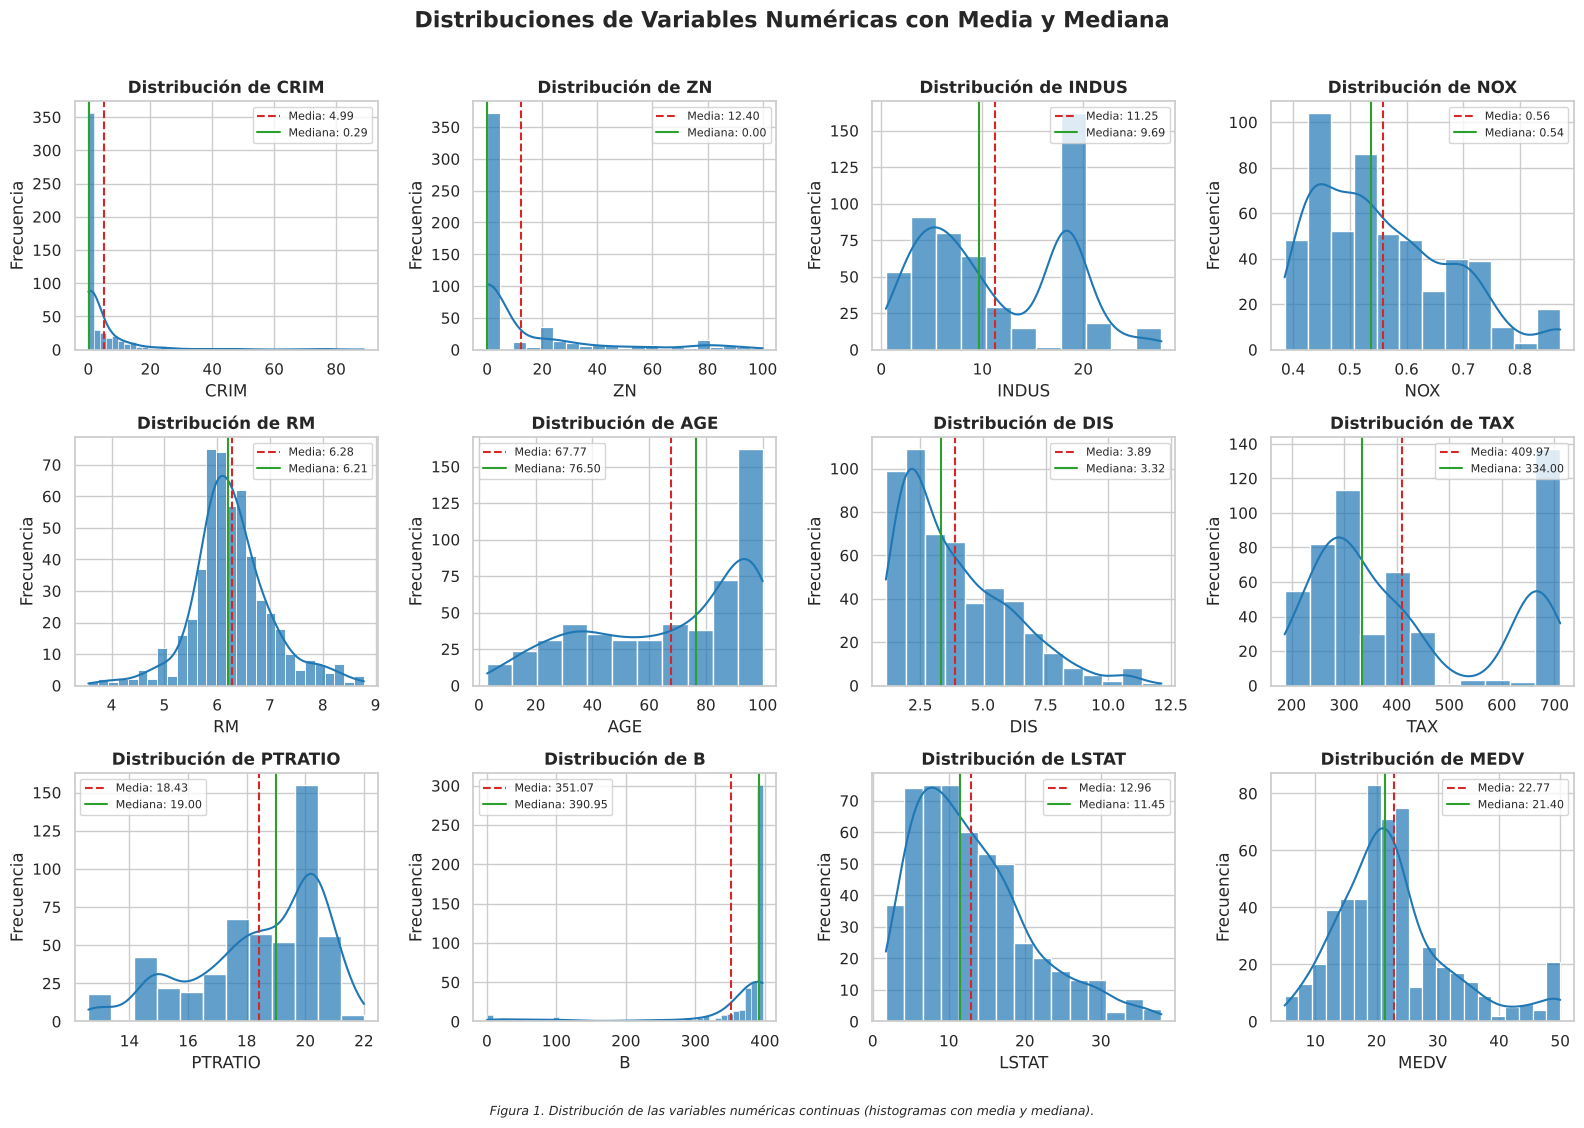

In [16]:
# Histogramas de las continuas con media y mediana
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    sns.histplot(df_casas_limpio[col], kde=True, ax=ax, color='tab:blue',
                 edgecolor='white', alpha=0.7)

    # Líneas de referencia: media y mediana
    media = df_casas_limpio[col].mean()
    mediana = df_casas_limpio[col].median()
    ax.axvline(media, color='tab:red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='tab:green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivamos los ejes basándonos en la nueva cantidad de columnas
for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.09)
plt.figtext(0.5, 0.005, 'Figura 1. Distribución de las variables numéricas continuas (histogramas con media y mediana).',
            ha='center', fontsize=9, style='italic')
plt.show()

In [17]:
# Asimetría (skew) de cada variable continua: 0 es simétrica, positiva es cola a la derecha
df_casas_limpio[columnas_numericas].skew().round(2)

CRIM       4.1400
ZN         2.0700
INDUS      0.3000
NOX        0.7100
RM         0.2600
AGE       -0.5600
DIS        1.0700
TAX        0.6400
PTRATIO   -0.7900
B         -2.5700
LSTAT      0.9600
MEDV       1.0700
dtype: float64

### ¿Qué muestran las distribuciones?

Casi todas las variables son **asimétricas**: la media se aleja de la mediana (Figura 1) y el skew se aleja de 0. Por eso más adelante usamos herramientas robustas a los extremos: IQR, Spearman y `RobustScaler`.

- `CRIM`: va de 0.01 a 88.98, con media 4.99 contra mediana 0.29 (skew 4.14). Unos pocos barrios muy peligrosos arrastran el promedio.
- `ZN`: mediana 0; la mayoría de los barrios vale cero (*zero-inflated*, primera barra de la Figura 1).
- `INDUS` y `RM`: casi simétricas (skew 0.30 y 0.26).
- `NOX`: va de 0.38 a 0.87, una escala muy distinta al resto; sin escalar pesaría poco en las distancias de KNN.
- `AGE` y `PTRATIO`: cola hacia valores bajos (skew -0.56 y -0.79).
- `DIS`, `LSTAT` y `MEDV`: cola hacia valores altos (skew 1.07, 0.96 y 1.07). En `MEDV`, el target, se ve un pico en 50 que parece un techo del dataset.
- `TAX`: bimodal, con un grupo separado entre 666 y 711; correlaciona 0.90 con `RAD` (Figura 4), señal de multicolinealidad.
- `B`: cola fuerte hacia valores bajos (skew -2.57); esa minoría es la parte más informativa de la variable.

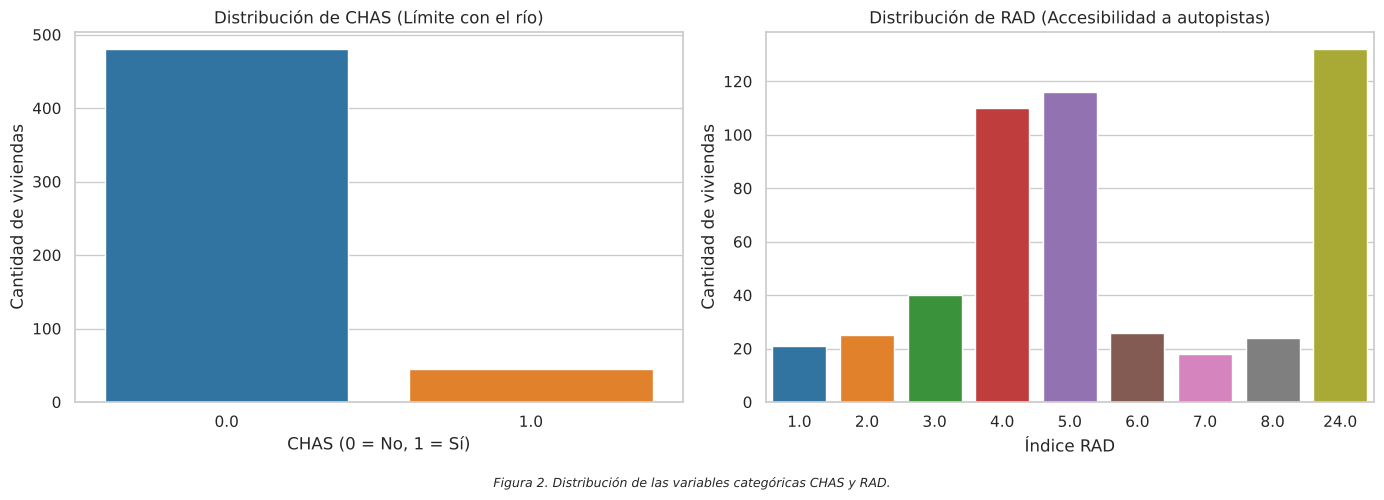

In [18]:
# Conteo de las categóricas CHAS y RAD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_casas_limpio, x='CHAS', ax=axes[0], palette='tab10')
axes[0].set_title('Distribución de CHAS (Límite con el río)')
axes[0].set_xlabel('CHAS (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de viviendas')

sns.countplot(data=df_casas_limpio, x='RAD', ax=axes[1], palette='tab10')
axes[1].set_title('Distribución de RAD (Accesibilidad a autopistas)')
axes[1].set_xlabel('Índice RAD')
axes[1].set_ylabel('Cantidad de viviendas')

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.01, 'Figura 2. Distribución de las variables categóricas CHAS y RAD.',
            ha='center', fontsize=9, style='italic')
plt.show()

### Lectura de los gráficos

`CHAS` está muy desbalanceada: 480 viviendas no limitan con el río y 45 sí (91 % de ceros). `RAD` se concentra en 4 (110 viviendas), 5 (116) y 24 (132), y el 24 queda separado del resto del índice. Promediar cualquiera de las dos con KNN daría valores que no existen, como 0.3 en `CHAS` o 10.5 en `RAD`, así que las imputamos con `CatBoostClassifier`.

### Codificación de variables categóricas

`CHAS` ya viene codificada como 0 y 1, así que no necesita transformación.

`RAD` es un índice ordinal: un valor más alto indica mejor acceso a autopistas. En la regresión la dejamos numérica, para no sumar ocho columnas con pocas filas cada una. Solo la tratamos como categórica al imputar, para no generar valores que no existen en el índice.

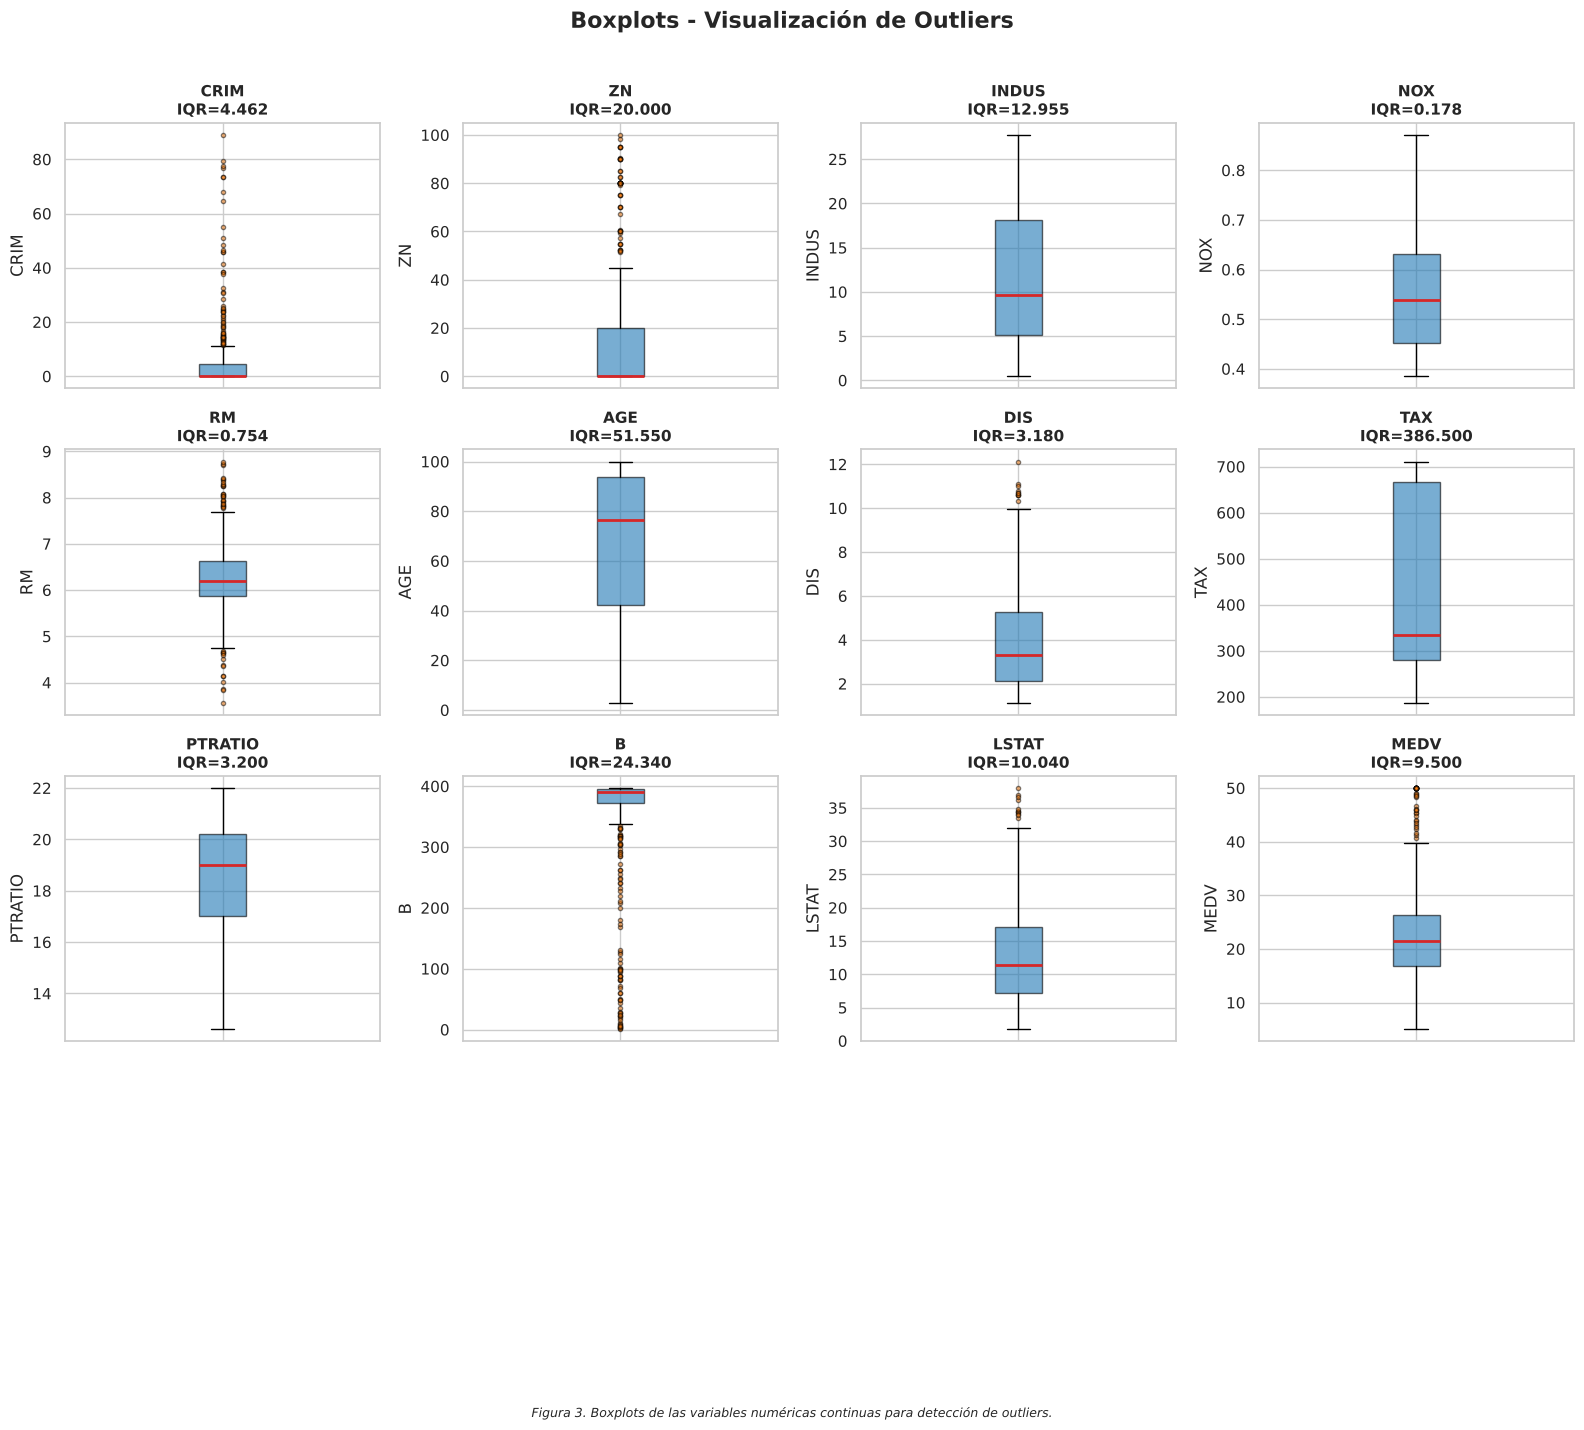

In [19]:
# Boxplots de las continuas, con el IQR en el título
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    datos = df_casas_limpio[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='tab:blue', alpha=0.6),
                    medianprops=dict(color='tab:red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='tab:orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualización de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.04)
plt.figtext(0.5, 0.005, 'Figura 3. Boxplots de las variables numéricas continuas para detección de outliers.',
            ha='center', fontsize=9, style='italic')
plt.show()

In [20]:
# Tests de normalidad de Shapiro-Wilk y D'Agostino-Pearson por variable
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Sí' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.4593,0.0000,474.8110,0.0000,No
1,ZN,0.5797,0.0000,212.0894,0.0000,No
2,INDUS,0.9066,0.0000,358.1683,0.0000,No
3,NOX,0.9363,0.0000,37.7920,0.0000,No
4,RM,0.9649,0.0000,26.3030,0.0000,No
5,AGE,0.8942,0.0000,154.8825,0.0000,No
6,DIS,0.9001,0.0000,78.4015,0.0000,No
7,TAX,0.8243,0.0000,307.0383,0.0000,No
8,PTRATIO,0.9067,0.0000,46.7652,0.0000,No
9,B,0.5156,0.0000,280.3340,0.0000,No


Los tests de Shapiro-Wilk y D'Agostino-Pearson rechazan la normalidad, así que en lugar del z-score usamos el método IQR, basado en cuartiles.

In [21]:
# Límites IQR y cantidad de outliers por variable
IQR_FACTOR = 1.5

reporte_outliers = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()
    n = len(datos)

    # Método IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Método IQR')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)']]

Reporte de Outliers: Método IQR


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%)
0,CRIM,524,4.4619,-6.6092,11.2382,64,12.2137
1,ZN,521,20.0000,-30.0000,50.0000,54,10.3647
2,INDUS,530,12.9550,-14.2875,37.5325,0,0.0000
3,NOX,525,0.1780,0.1860,0.8980,0,0.0000
4,RM,526,0.7545,4.7445,7.7625,41,7.7947
5,AGE,523,51.5500,-34.9750,171.2250,0,0.0000
6,DIS,529,3.1804,-2.6637,10.0579,10,1.8904
7,TAX,523,386.5000,-300.2500,1245.7500,0,0.0000
8,PTRATIO,524,3.2000,12.2000,25.0000,0,0.0000
9,B,525,24.3400,335.2100,432.5700,86,16.3810


In [22]:
# Correlaciones de Pearson (lineal) y Spearman (por rangos)
matriz_pearson = df_casas_limpio.corr(method='pearson')
matriz_spearman = df_casas_limpio.corr(method='spearman')


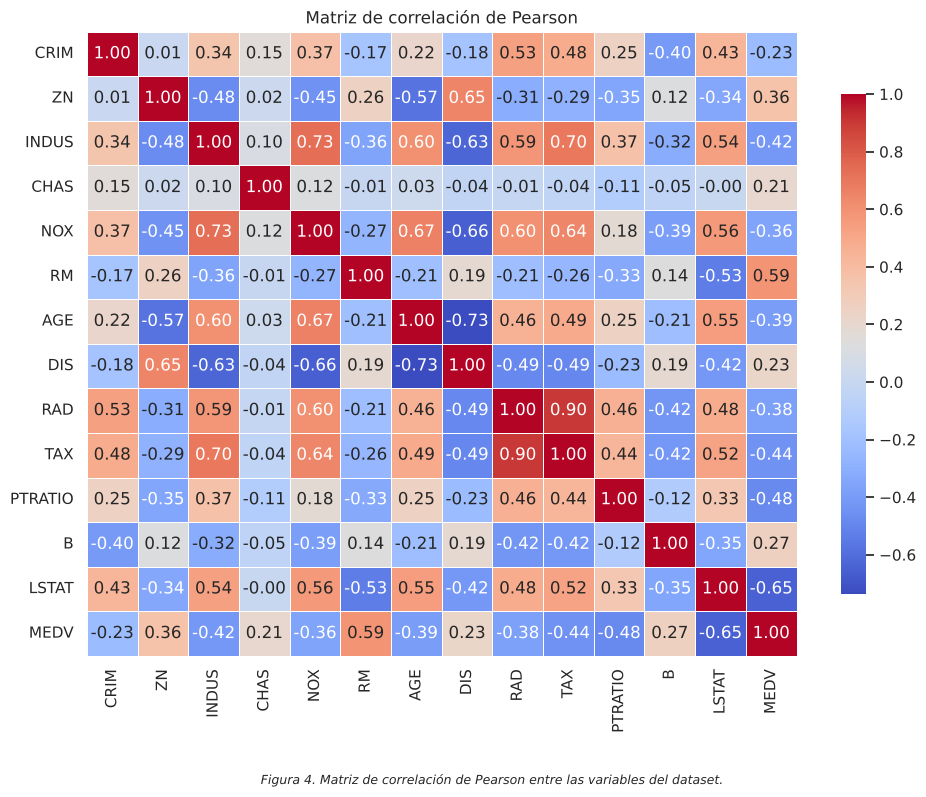

In [23]:
# Matriz de Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(data=matriz_pearson, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor='white', cbar_kws={"shrink": .8})
plt.title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.01, 'Figura 4. Matriz de correlación de Pearson entre las variables del dataset.',
            ha='center', fontsize=9, style='italic')
plt.show()

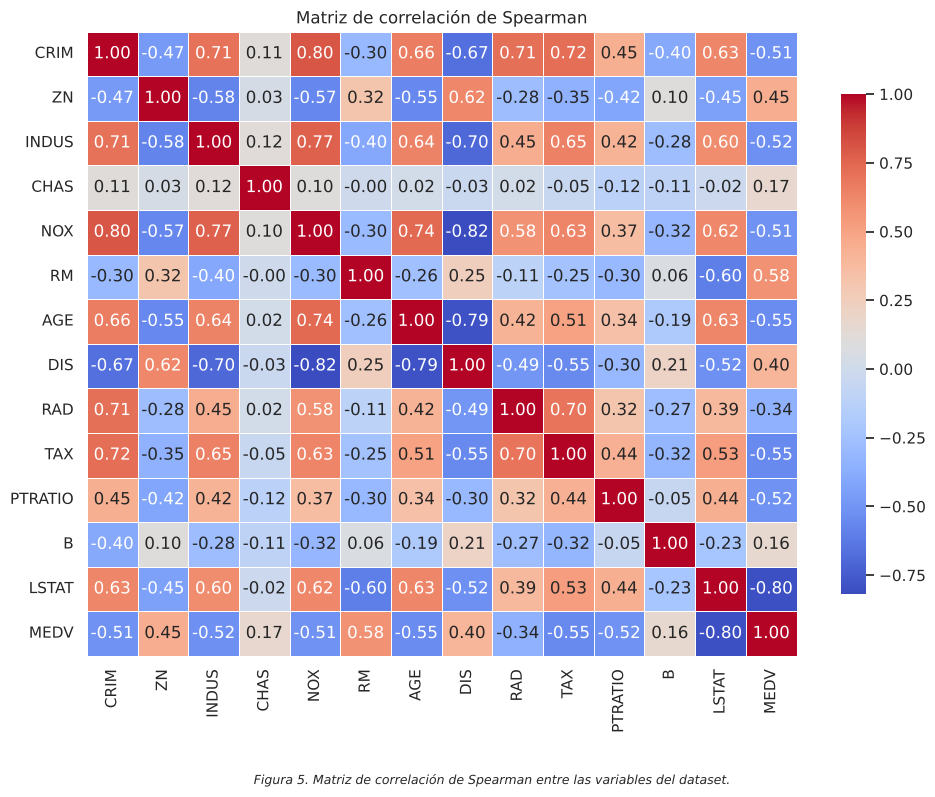

In [24]:
# Matriz de Spearman; coolwarm porque la correlación va de -1 (azul) a 1 (rojo)
plt.figure(figsize=(10, 8))
sns.heatmap(data=matriz_spearman, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor='white', cbar_kws={"shrink": .8})
plt.title('Matriz de correlación de Spearman')
plt.tight_layout()
plt.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.01, 'Figura 5. Matriz de correlación de Spearman entre las variables del dataset.',
            ha='center', fontsize=9, style='italic')
plt.show()

## Conclusiones de la matriz de correlación

Tomamos Spearman (Figura 5) como referencia: trabaja con rangos, así que no lo distorsionan los outliers ni las asimetrías que rompen los supuestos de Pearson (Figura 4).

1. Con el target, la relación más fuerte es `LSTAT` (-0.80): más población de bajo estatus en el barrio, menor precio. Le sigue `RM` (0.58): más habitaciones, mayor precio. `AGE`, `TAX`, `INDUS`, `PTRATIO`, `CRIM` y `NOX` rondan -0.5.
2. `RAD`-`TAX`: 0.90 con Pearson y 0.70 con Spearman, **multicolinealidad** real. Las zonas más urbanizadas tienen impuestos más altos y mejor acceso a autopistas.
3. `CRIM`: con Pearson parece aislada (`CRIM`-`ZN` = 0.01), pero con Spearman aparece conectada (`CRIM`-`NOX` = 0.80, `CRIM`-`TAX` = 0.72). Unos pocos barrios extremos distorsionan el coeficiente lineal.

## Coherencia de los outliers (CRIM, ZN y B)

IQR marca muchos outliers en estas variables, pero casi todos son la cola de distribuciones asimétricas y no errores de carga. Contrastamos cada uno con las relaciones que predice la matriz de correlación: si rompe la mayoría, lo marcamos como incoherente.

In [25]:
# Outliers IQR de una columna, marcando si están del lado alto o bajo
def detectar_outliers_iqr(df, columna):
    serie = df[columna].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df_outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)].copy()
    df_outliers['lado'] = np.where(df_outliers[columna] > lim_sup, 'alto', 'bajo')
    return df_outliers, lim_inf, lim_sup

### Función: chequear coherencia

Compara cada outlier contra la mediana de las variables relacionadas y cuenta cuántas relaciones esperadas rompe.

- `direccion`: signo de la correlación con el target (+1 o -1).
- `relaciones`: `{variable: signo_esperado}` para otras variables del dominio.
- `umbral_fraccion`: fracción de relaciones rotas a partir de la cual la fila es incoherente.

Los NaN no se evalúan: solo achican el denominador.

In [26]:
# Marca como incoherente al outlier que rompe al menos umbral_fraccion de sus relaciones esperadas
def chequear_coherencia(df, columna, direccion, relaciones=None, target='MEDV',
                         umbral_fraccion=0.5):
    df_outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, columna)
    signo_lado = np.where(df_outliers['lado'] == 'alto', 1, -1)

    def marca_rompe(var, signo_esperado):
        mediana_var = df[var].median(skipna=True)
        diff = df_outliers[var] - mediana_var
        signo_fila = np.sign(diff)
        signo_esperado_fila = signo_lado * signo_esperado
        evaluable = diff.notna() & (signo_fila != 0)
        rompe = evaluable & (np.sign(signo_esperado_fila) != signo_fila)
        return evaluable, rompe

    todas_las_relaciones = [(target, direccion)] + list((relaciones or {}).items())
    n_evaluables = pd.Series(0, index=df_outliers.index)
    n_rotas = pd.Series(0, index=df_outliers.index)
    for var, signo_var in todas_las_relaciones:
        evaluable, rompe = marca_rompe(var, signo_var)
        df_outliers[f'rompe_{var}'] = rompe
        n_evaluables += evaluable.astype(int)
        n_rotas += rompe.astype(int)

    df_outliers['n_evaluables'] = n_evaluables
    df_outliers['n_rotas'] = n_rotas
    df_outliers['fraccion_rota'] = np.where(n_evaluables > 0, n_rotas / n_evaluables, 0.0)

    df_incoherentes = (
        df_outliers[(df_outliers['n_evaluables'] > 0) &
                    (df_outliers['fraccion_rota'] >= umbral_fraccion)]
        .sort_values(['fraccion_rota', 'n_evaluables'], ascending=False)
    )

    print(f"--- {columna} ---")
    print(f"  límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}]  -> {len(df_outliers)} outliers totales")
    print(f"  incoherentes (rompen >={umbral_fraccion*100:.0f}% de lo evaluable): {len(df_incoherentes)}")

    return df_outliers, df_incoherentes

### Función: graficar coherencia

Outliers contra `MEDV`, separados en coherentes (se conservan) e incoherentes (a revisar).

In [27]:
# Outliers contra el target: normales en gris, coherentes en naranja, incoherentes en rojo
def graficar_coherencia(df, columna, df_outliers, df_incoherentes, target='MEDV', fig_num=None):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=columna, y=target, color='tab:gray', alpha=0.6,
                     label='Datos normales')

    coherentes = df_outliers.drop(df_incoherentes.index)
    sns.scatterplot(data=coherentes, x=columna, y=target, color='tab:orange', edgecolor='black',
                     label='Outlier coherente (conservar)')

    sns.scatterplot(data=df_incoherentes, x=columna, y=target, color='tab:red', edgecolor='black',
                     s=90, label='Outlier incoherente (revisar)')

    plt.title(f'Coherencia de outliers de {columna} respecto a {target}')
    plt.xlabel(columna)
    plt.ylabel(target)
    plt.legend()
    if fig_num is not None:
        plt.subplots_adjust(bottom=0.14)
        plt.figtext(0.5, 0.01, f'Figura {fig_num}. Coherencia de outliers de {columna} respecto a {target}.',
                    ha='center', fontsize=9, style='italic')
    plt.show()

### Signos esperados por variable

Salen de la matriz de correlación:

- `CRIM`: negativo con `MEDV`, negativo con `RM`, positivo con `LSTAT`.
- `ZN`: positivo con `MEDV`, negativo con `INDUS`, negativo con `LSTAT`.
- `B`: positivo con `MEDV`, negativo con `LSTAT`.

In [28]:
# Signo esperado de cada relación, sacado de la matriz de correlación
config = {
    'CRIM': dict(direccion=-1, relaciones={'RM': -1, 'LSTAT': 1}),
    'ZN':   dict(direccion=+1, relaciones={'INDUS': -1, 'LSTAT': -1}),
    'B':    dict(direccion=+1, relaciones={'LSTAT': -1}),
}

### Análisis de CRIM, ZN y B

Con `umbral_fraccion=0.5`, una fila es incoherente si rompe la mayoría de sus relaciones evaluables.

--- CRIM ---
  límites IQR: [-6.61, 11.24]  -> 64 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 10


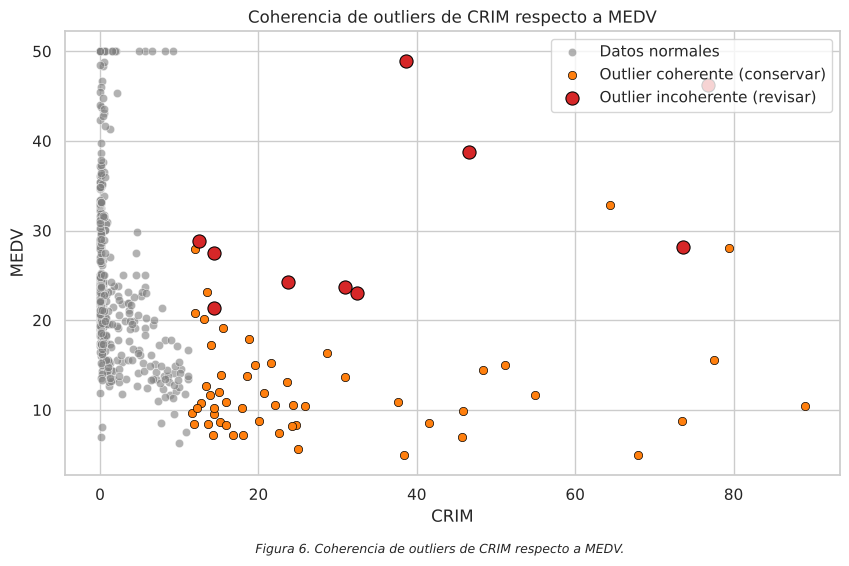

--- ZN ---
  límites IQR: [-30.00, 50.00]  -> 54 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 6


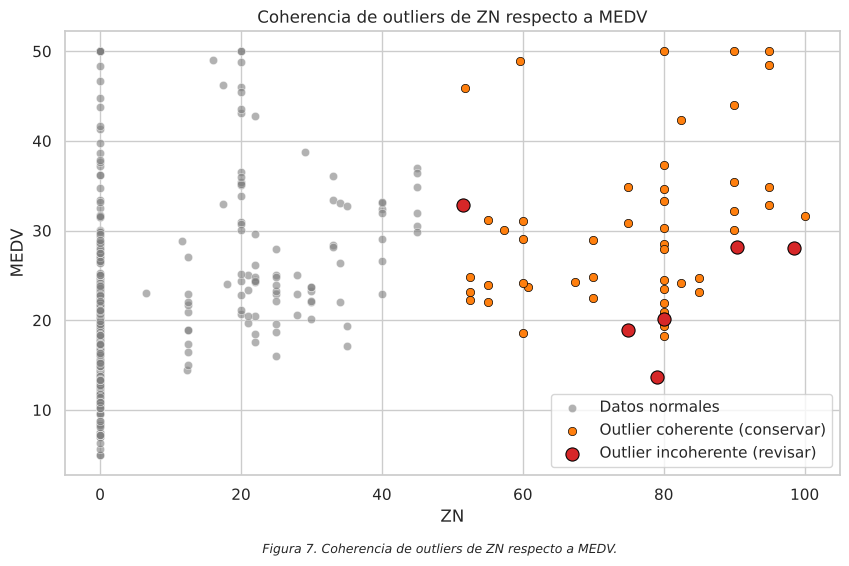

--- B ---
  límites IQR: [335.21, 432.57]  -> 86 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 21


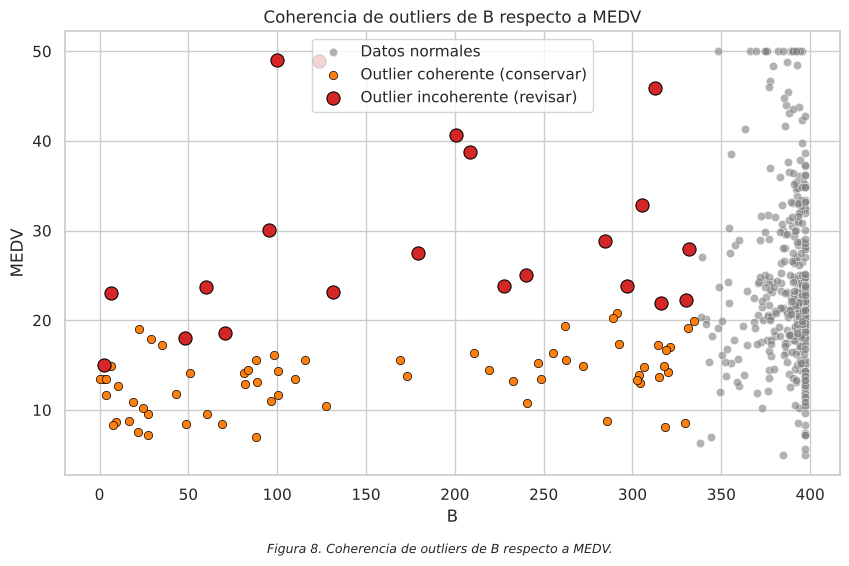

In [29]:
# Chequeamos y graficamos CRIM, ZN y B
resultados = {}
for i, (col, cfg) in enumerate(config.items()):
    outliers, incoherentes = chequear_coherencia(df_casas_limpio, col, **cfg, umbral_fraccion=0.5)
    resultados[col] = (outliers, incoherentes)
    graficar_coherencia(df_casas_limpio, col, outliers, incoherentes, fig_num=6 + i)

### Triangulación entre variables

Una fila incoherente en más de una variable es un candidato más fuerte a revisión que una incoherente en una sola.

In [30]:
# Filas incoherentes en al menos dos variables
indices = [set(incoh.index) for _, incoh in resultados.values()]
interseccion = set.union(*[
    indices[i] & indices[j]
    for i in range(len(indices)) for j in range(i + 1, len(indices))
])

print('Filas incoherentes en más de una variable:', sorted(interseccion))

cols_mostrar = ['CRIM', 'ZN', 'B', 'RM', 'LSTAT', 'INDUS', 'MEDV']
df_casas_limpio.loc[sorted(interseccion), cols_mostrar]

Filas incoherentes en más de una variable: [14, 23, 264, 298, 316, 458, 520, 554]


,CRIM,ZN,B,RM,LSTAT,INDUS,MEDV
14,30.9865,60.7115,60.1620,NaN,30.4948,8.8272,23.6754
23,73.6057,90.4347,NaN,8.0501,NaN,12.7403,28.1301
264,38.6081,59.5613,123.4545,3.8395,3.3899,15.5515,48.8545
298,14.4383,0.0000,179.3600,6.8520,19.7800,18.1000,27.5000
316,46.6368,29.0858,208.3193,4.5902,9.7974,23.6764,38.7155
458,12.5105,11.6104,284.7875,7.9491,27.7894,14.4042,28.8124
520,64.4546,51.5727,305.3963,5.6565,33.9643,12.8320,32.8579
554,32.5040,6.5286,6.2671,4.0166,7.0340,8.9373,23.0288


## Separación en train y test, e imputación con KNNImputer

Separamos train y test antes de escalar e imputar, para evitar **fuga de datos**: el escalador y el imputador aprenden solo de train. El análisis de outliers de la sección anterior sí usó el dataset completo. Por eso las filas trianguladas se eliminan solo si cayeron en train; test queda intacto, como los datos reales.

In [31]:
# Split 80/20 y sacamos de train las filas trianguladas
from sklearn.model_selection import train_test_split

X = df_casas_limpio.drop(columns='MEDV')
y = df_casas_limpio['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

filas_a_eliminar = sorted(interseccion)
filas_en_train = [i for i in filas_a_eliminar if i in X_train.index]
filas_en_test = [i for i in filas_a_eliminar if i in X_test.index]

print(f'Se eliminan de train: {filas_en_train}')
print(f'Se conservan en test (aunque estén en la lista): {filas_en_test}')

X_train = X_train.drop(index=filas_en_train)
y_train = y_train.drop(index=filas_en_train)

Se eliminan de train: [14, 23, 264, 298, 316, 458, 554]
Se conservan en test (aunque estén en la lista): [520]


### Escalado con RobustScaler

Usa mediana e IQR, así que no lo arrastran los outliers legítimos que conservamos en `CRIM`, `ZN` y `B`, como pasaría con `StandardScaler`. Se ajusta con train y se aplica a test.

In [32]:
# RobustScaler solo sobre las continuas: se ajusta con train y se aplica a test
from sklearn.preprocessing import RobustScaler

columnas_continuas = [c for c in X_train.columns if c not in ['CHAS', 'RAD']]

scaler = RobustScaler()
X_train_esc = X_train.copy()
X_train_esc[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])

X_test_esc = X_test.copy()
X_test_esc[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

### Efecto del escalado

Antes y después de `RobustScaler`: medianas centradas y escalas comparables entre variables.

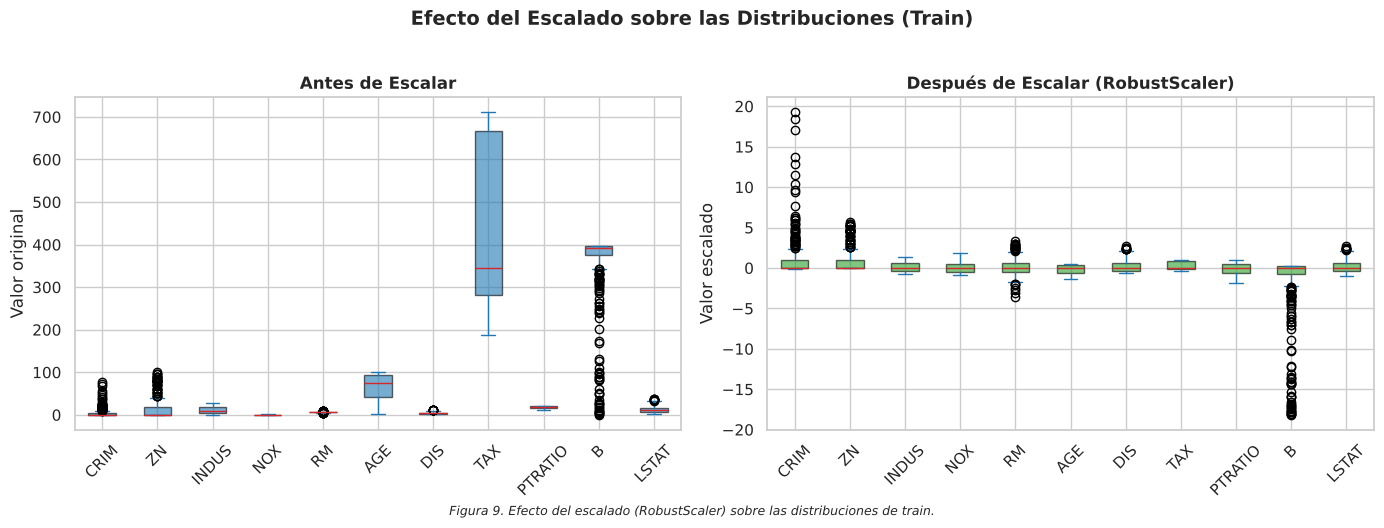

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
X_train[columnas_continuas].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='tab:blue', alpha=0.6),
    medianprops=dict(color='tab:red'))
axes[0].set_title('Antes de Escalar', fontweight='bold')
axes[0].set_ylabel('Valor original')
axes[0].tick_params(axis='x', rotation=45)

# Después
X_train_esc[columnas_continuas].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='tab:green', alpha=0.6),
    medianprops=dict(color='tab:red'))
axes[1].set_title('Después de Escalar (RobustScaler)', fontweight='bold')
axes[1].set_ylabel('Valor escalado')
axes[1].tick_params(axis='x', rotation=45)
# Boxplots de train antes y después de RobustScaler
plt.suptitle('Efecto del Escalado sobre las Distribuciones (Train)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.01, 'Figura 9. Efecto del escalado (RobustScaler) sobre las distribuciones de train.',
            ha='center', fontsize=9, style='italic')
plt.show()

## Método del codo para elegir `n_neighbors` (KNNImputer)

La cantidad de vecinos `k` es un **hiperparámetro**. Para elegirlo borramos a propósito valores conocidos de las filas completas de train, los imputamos con distintos `k` y medimos el error de reconstrucción (NRMSE). Todo con train, para no filtrar información de test.

In [34]:
# Imputador por vecinos más cercanos
from sklearn.impute import KNNImputer

### Función: enmascarar y medir

Oculta al azar una fracción de celdas, las imputa con `k` vecinos y devuelve el NRMSE sobre esas celdas, normalizado por el desvío de cada columna.

In [35]:
# Oculta celdas al azar, las imputa y mide el error normalizado (NRMSE)
def enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng):
    mascara = rng.random(datos_verdad.shape) < fraccion_mascara
    datos_enmascarados = datos_verdad.copy()
    datos_enmascarados[mascara] = np.nan

    imputer = KNNImputer(n_neighbors=k)
    reconstruido = imputer.fit_transform(datos_enmascarados)

    std_cols = datos_verdad.std(axis=0)
    error = (reconstruido[mascara] - datos_verdad[mascara]) ** 2
    std_expandido = np.tile(std_cols, (datos_verdad.shape[0], 1))[mascara]
    return np.sqrt(np.mean(error / (std_expandido ** 2 + 1e-12)))

### Función: curva del codo

Repite el experimento `n_repeticiones` veces por cada `k` y devuelve la media y el desvío del NRMSE.

In [36]:
# NRMSE medio y desvío para cada k, repitiendo con distintas semillas
def curva_del_codo(datos_verdad, ks, n_repeticiones=15, fraccion_mascara=0.05):
    filas = []
    for k in ks:
        errores = []
        for rep in range(n_repeticiones):
            rng = np.random.default_rng(rep)
            errores.append(enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng))
        filas.append({
            'k': k,
            'nrmse_medio': np.mean(errores),
            'nrmse_std': np.std(errores),
        })
    return pd.DataFrame(filas)

### Función: graficar el codo

NRMSE promedio (± desvío) según `k`.

In [37]:
# Gráfico del NRMSE según k
def graficar_codo(tabla_resultados):
    plt.figure(figsize=(9, 5))
    plt.plot(
        tabla_resultados['k'], tabla_resultados['nrmse_medio'],
        marker='o', linewidth=2
    )
    plt.title('Método del codo para elegir n_neighbors (KNNImputer)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('NRMSE promedio (experimento de enmascaramiento)')
    plt.grid(alpha=0.3)
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(0.5, 0.01, 'Figura 10. Método del codo: NRMSE promedio vs. n_neighbors (k) para KNNImputer.',
                ha='center', fontsize=9, style='italic')
    plt.show()


### Función: elegir k por curvatura

Calcula el codo en vez de elegirlo a ojo: es el `k` con mayor derivada segunda del NRMSE en valor absoluto, donde la curva pasa más bruscamente de bajar a aplanarse. Cada derivada se divide por la distancia real entre los `k`, que no están espaciados de forma uniforme.

In [38]:
def calcular_derivadas_codo(tabla_resultados):
    tabla_ordenada = tabla_resultados.sort_values('k').reset_index(drop=True)
    k = tabla_ordenada['k'].to_numpy(dtype=float)
    y = tabla_ordenada['nrmse_medio'].to_numpy()

    # Derivada primera: pendiente del NRMSE entre cada par de k consecutivos
    derivada_1 = np.diff(y) / np.diff(k)
    k_medios = (k[1:] + k[:-1]) / 2

    # Derivada segunda: cuanto cambia la pendiente de un tramo al siguiente
    derivada_2 = np.diff(derivada_1) / np.diff(k_medios)
    k_curvatura = k[1:-1]

    return pd.DataFrame({'k': k_curvatura.astype(int), 'derivada_segunda': derivada_2})


def elegir_k_por_curvatura(tabla_resultados):
    derivadas = calcular_derivadas_codo(tabla_resultados)
    idx_codo = derivadas['derivada_segunda'].abs().idxmax()
    k_elegido = int(derivadas.loc[idx_codo, 'k'])
    return k_elegido, derivadas


### Función: graficar la curvatura del codo

Derivada segunda del NRMSE según `k`, con el codo marcado.

In [39]:
# Gráfico de la derivada segunda, con el k elegido marcado
def graficar_curvatura_codo(derivadas, k_elegido):
    plt.figure(figsize=(9, 5))
    plt.plot(derivadas['k'], derivadas['derivada_segunda'], marker='o')
    plt.axvline(k_elegido, color='tab:red', linestyle='--', label=f'k elegido = {k_elegido}')
    plt.title('Curvatura de la curva del codo (derivada segunda del NRMSE)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('Derivada segunda del NRMSE promedio')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(0.5, 0.01, 'Figura 11. Derivada segunda del NRMSE vs. k: el máximo en valor absoluto marca el codo (mayor cambio de pendiente).',
                ha='center', fontsize=9, style='italic')
    plt.show()


### Ejecutamos el experimento

Solo con las filas completas de `X_train_esc`.

In [40]:
# Usamos solo filas completas de train, así conocemos el valor real de lo que ocultamos
completas = X_train_esc[columnas_continuas].dropna().copy()
print(f'Filas completas en train usadas para el experimento: {completas.shape[0]}')

datos_verdad = completas.to_numpy()
ks_a_probar = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

tabla = curva_del_codo(datos_verdad, ks_a_probar, n_repeticiones=15, fraccion_mascara=0.05)
tabla

Filas completas en train usadas para el experimento: 405


,k,nrmse_medio,nrmse_std
0,1,0.7390,0.0889
1,2,0.6477,0.0627
2,3,0.6314,0.0631
3,4,0.6248,0.0647
4,5,0.6227,0.0637
5,7,0.6312,0.0547
6,10,0.6374,0.0512
7,15,0.6524,0.0571
8,20,0.6636,0.0584
9,25,0.6727,0.0602


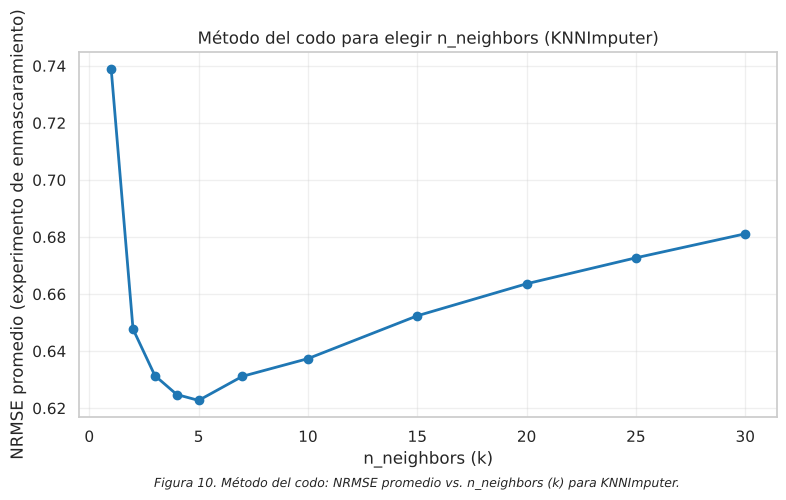

In [41]:
# Curva del codo
graficar_codo(tabla)

### Interpretamos el resultado

La curva de la Figura 10 no tiene un codo clásico: baja hasta `k = 5` (NRMSE 0.623) y después sube, porque con muchos vecinos se promedian filas poco parecidas. La mayor curvatura está en `k = 2` (NRMSE 0.648): el salto grande ocurre de 1 a 2 vecinos, y de 2 a 5 el error baja solo 0.025. Elegimos `k = 2` por el criterio de curvatura, sabiendo que `k = 5` daría un error de imputación algo menor.

Derivada segunda del NRMSE por k (curvatura):
    k  derivada_segunda
0   2            0.0750
1   3            0.0097
2   4            0.0046
3   5            0.0042
4   7           -0.0009
5  10            0.0002
6  15           -0.0002
7  20           -0.0001
8  25           -0.0000

k elegido (mayor curvatura, calculado analíticamente): 2


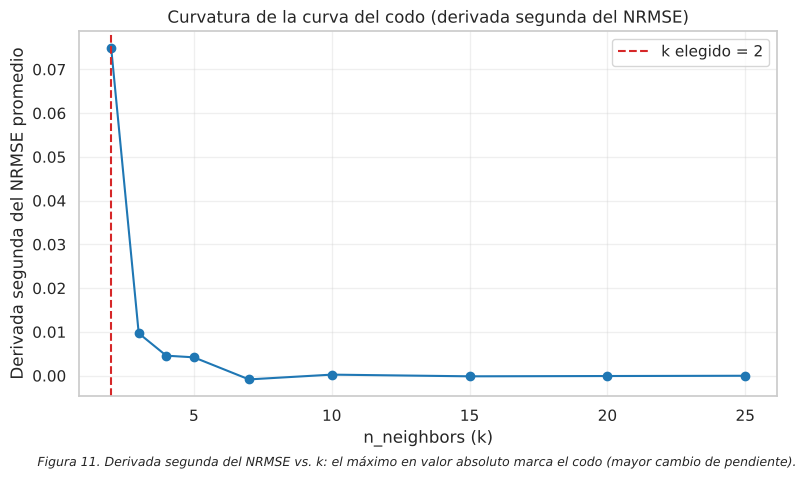

In [42]:
# Elegimos el k de mayor curvatura
k_elegido, derivadas_codo = elegir_k_por_curvatura(tabla)
print('Derivada segunda del NRMSE por k (curvatura):')
print(derivadas_codo)
print(f'\nk elegido (mayor curvatura, calculado analíticamente): {k_elegido}')

graficar_curvatura_codo(derivadas_codo, k_elegido)

## Imputación final con KNNImputer

Con el `k` elegido imputamos las columnas continuas. Los faltantes de test se completan con vecinos de train.

In [43]:
# El imputer se ajusta con train y completa test con vecinos de train
imputer = KNNImputer(n_neighbors=k_elegido)

X_train_imp = X_train_esc.copy()
X_train_imp[columnas_continuas] = imputer.fit_transform(X_train_esc[columnas_continuas])

X_test_imp = X_test_esc.copy()
X_test_imp[columnas_continuas] = imputer.transform(X_test_esc[columnas_continuas])

print('Nulos restantes en train:', X_train_imp[columnas_continuas].isnull().sum().sum())
print('Nulos restantes en test:', X_test_imp[columnas_continuas].isnull().sum().sum())

Nulos restantes en train: 0
Nulos restantes en test: 0


## Imputación de RAD y CHAS con CatBoostClassifier

Al ser categóricas no se pueden promediar, así que imputarlas es un problema de **clasificación**: `CatBoostClassifier` predice la categoría faltante a partir del resto de las variables. Se entrena con train y el mismo modelo completa test.

In [44]:
# Un clasificador por columna, entrenado con las filas de train que tienen el dato
from catboost import CatBoostClassifier

for col in ['RAD', 'CHAS']:
    features = [c for c in X_train_imp.columns if c != col]
    conocido = X_train_imp[X_train_imp[col].notna()]

    modelo = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=4,
        verbose=False, random_seed=42, allow_writing_files=False,
    )
    modelo.fit(conocido[features], conocido[col].astype(int))

    falta_train = X_train_imp[col].isna()
    falta_test = X_test_imp[col].isna()
    X_train_imp.loc[falta_train, col] = modelo.predict(X_train_imp.loc[falta_train, features]).flatten().astype(float)
    X_test_imp.loc[falta_test, col] = modelo.predict(X_test_imp.loc[falta_test, features]).flatten().astype(float)

print('Nulos restantes en RAD:', X_train_imp['RAD'].isnull().sum() + X_test_imp['RAD'].isnull().sum())
print('Nulos restantes en CHAS:', X_train_imp['CHAS'].isnull().sum() + X_test_imp['CHAS'].isnull().sum())

Nulos restantes en RAD: 0
Nulos restantes en CHAS: 0


## Distribuciones antes y después de imputar

`X_train_esc` (con nulos) contra `X_train_imp`, en la escala de `RobustScaler`. Una buena imputación rellena sin deformar la distribución: la parte naranja que sobresale es lo que agregó cada método.

In [45]:
# Juntamos train antes y después de imputar para graficarlos superpuestos
antes = X_train_esc.copy()
antes['Dataset'] = 'Antes de imputar'

despues = X_train_imp.copy()
despues['Dataset'] = 'Después de imputar'

comparacion = pd.concat([antes, despues], ignore_index=True)

In [46]:
# Chequeo del DataFrame combinado
comparacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     829 non-null    float64
 1   ZN       826 non-null    float64
 2   INDUS    834 non-null    float64
 3   CHAS     830 non-null    float64
 4   NOX      831 non-null    float64
 5   RM       832 non-null    float64
 6   AGE      830 non-null    float64
 7   DIS      834 non-null    float64
 8   RAD      828 non-null    float64
 9   TAX      832 non-null    float64
 10  PTRATIO  831 non-null    float64
 11  B        830 non-null    float64
 12  LSTAT    832 non-null    float64
 13  Dataset  834 non-null    str    
dtypes: float64(13), str(1)
memory usage: 91.3 KB


In [47]:
# Primeras filas del DataFrame combinado
comparacion.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Dataset
0,-0.0031,0.0000,0.0000,0.0000,0.0328,-0.6667,0.0328,0.2087,4.0000,-0.1039,-0.1061,0.2540,0.0050,Antes de imputar
1,0.0528,0.0000,0.0000,0.0000,0.0328,-0.1194,-0.3314,0.2266,4.0000,-0.1039,-0.1061,0.2451,0.1285,Antes de imputar
2,-0.0470,3.4401,-0.6330,0.0000,-0.6934,0.5057,-0.7726,2.3313,4.0000,0.1739,-0.1364,-0.9386,-0.5984,Antes de imputar
3,2.3290,0.0000,0.6322,0.0000,0.9555,0.7056,0.3487,-0.2459,24.0000,0.8360,0.4394,-17.8735,0.7289,Antes de imputar
4,0.0045,0.0000,-0.1943,0.0000,-0.2457,-0.6626,-0.0328,0.4522,5.0000,-0.1481,0.2576,0.0079,0.0291,Antes de imputar


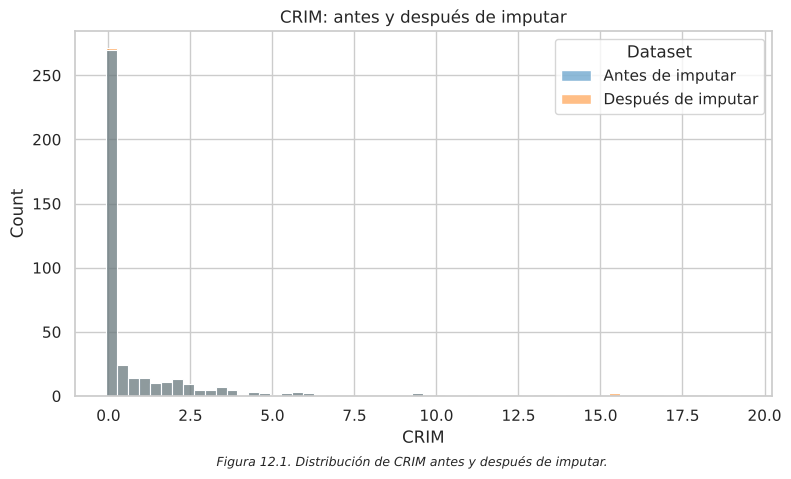

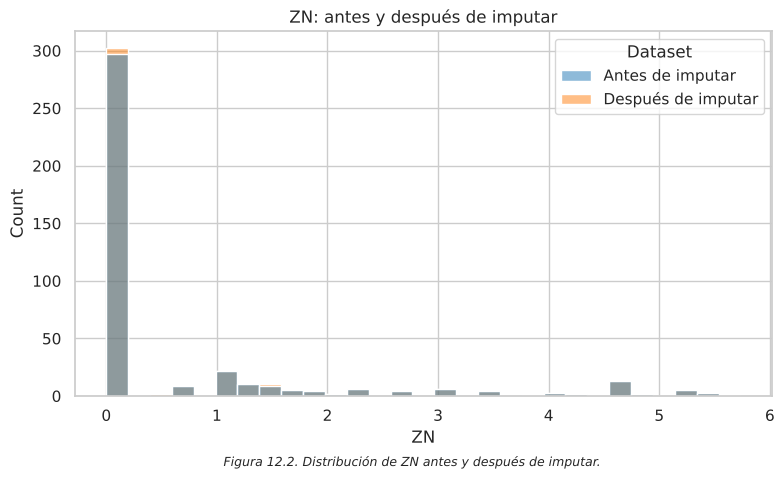

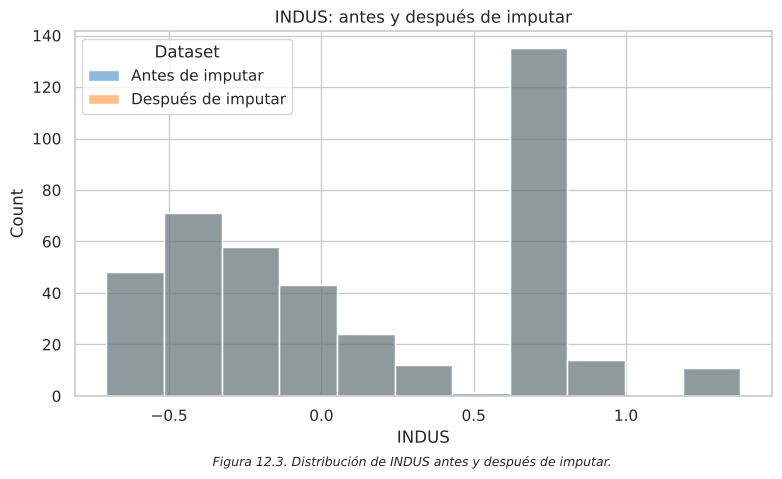

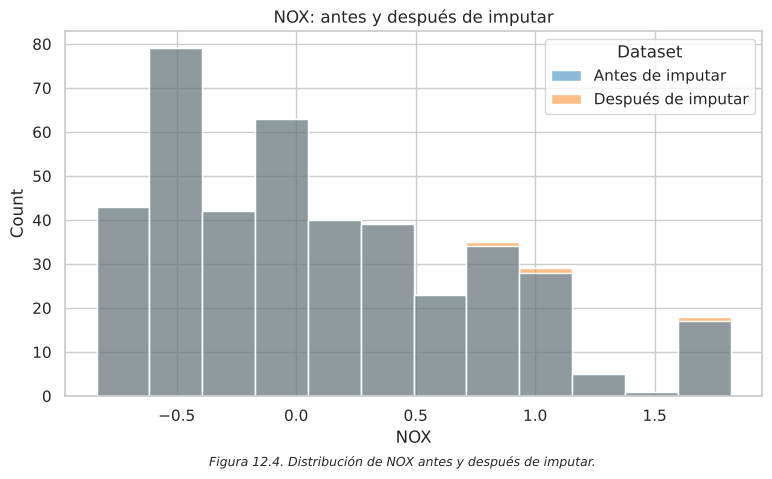

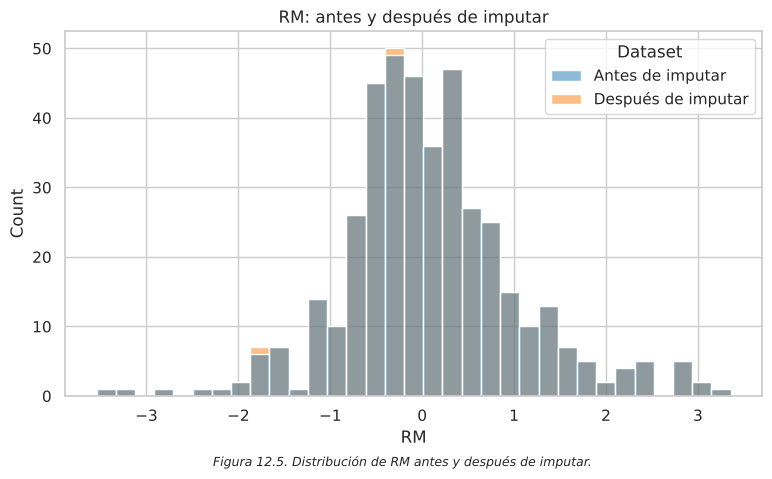

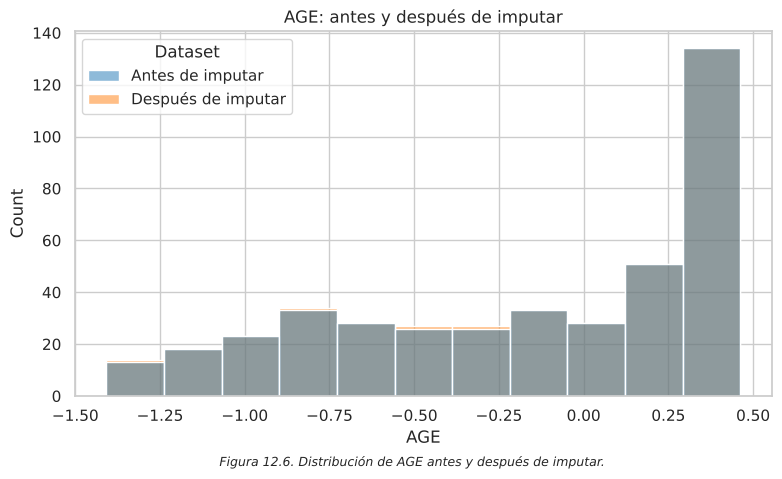

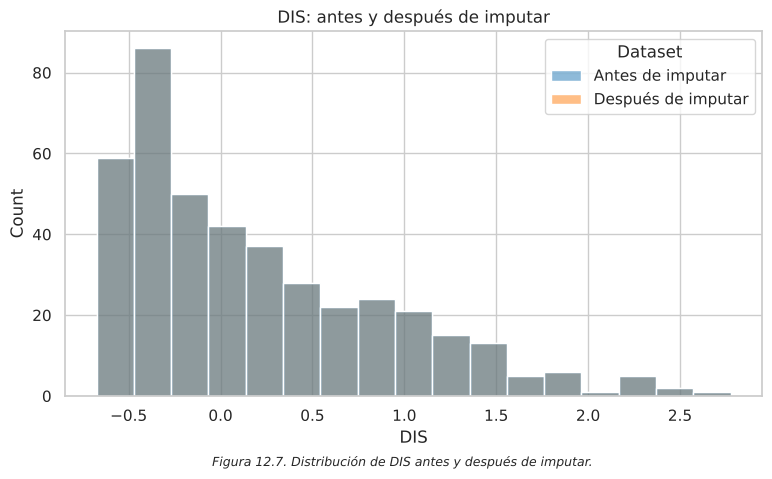

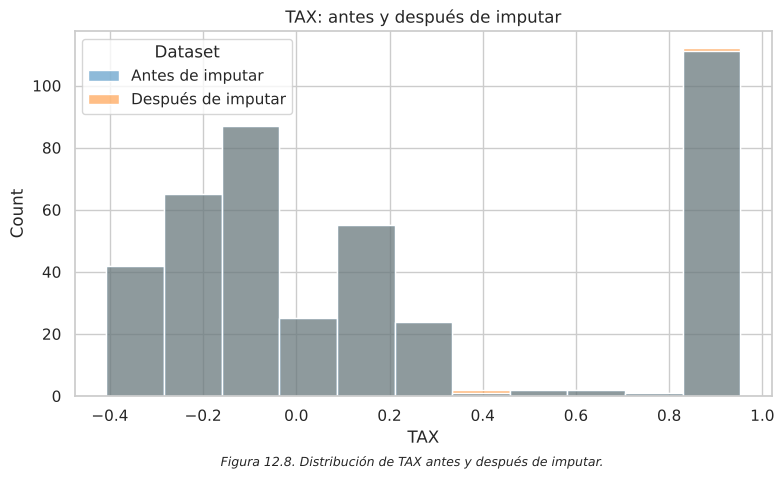

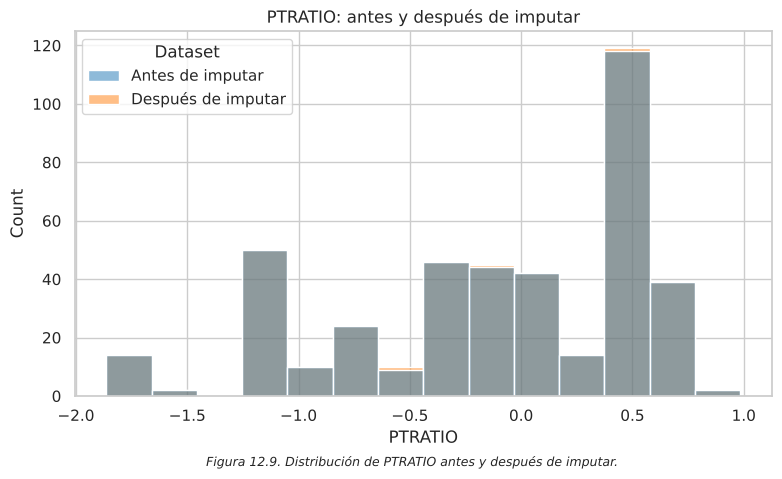

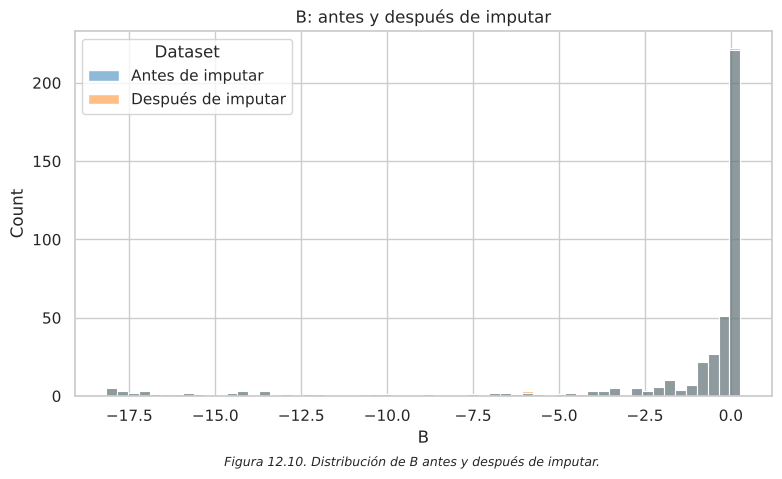

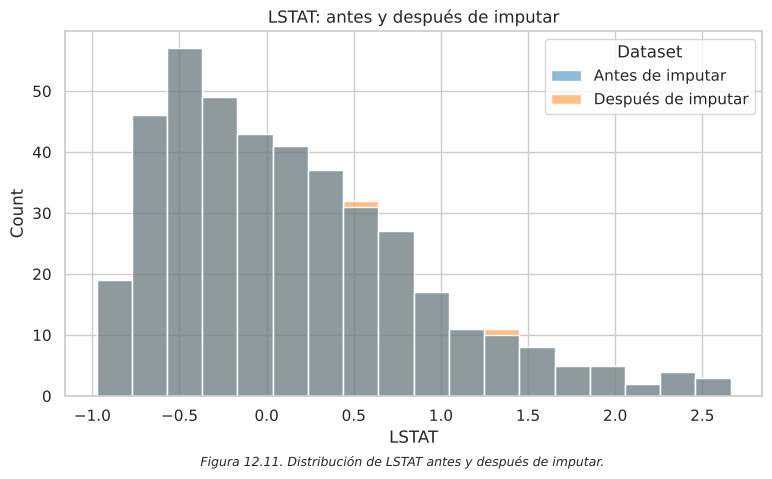

In [48]:
# Un histograma por variable continua, antes y después de imputar; CHAS y RAD van aparte
for i, col in enumerate(columnas_continuas, start=1):
    plt.figure(figsize=(9, 5))
    sns.histplot(data=comparacion, x=col, hue='Dataset', palette='tab10')
    plt.title(f'{col}: antes y después de imputar')
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(0.5, 0.01, f'Figura 12.{i}. Distribución de {col} antes y después de imputar.',
                ha='center', fontsize=9, style='italic')
    plt.show()

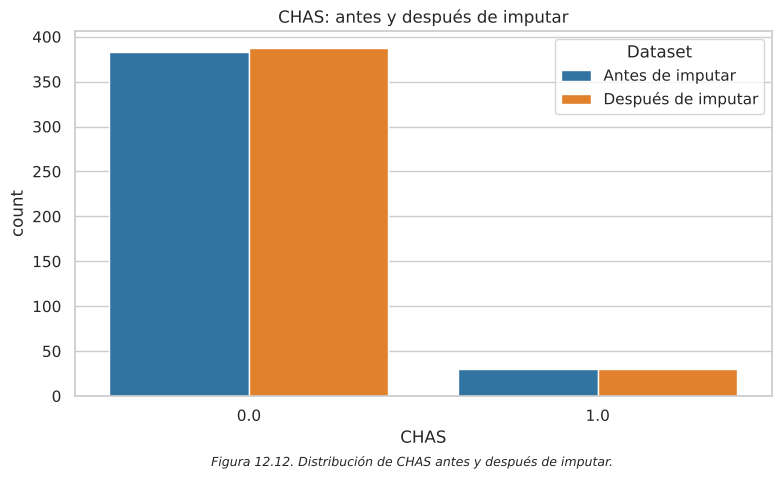

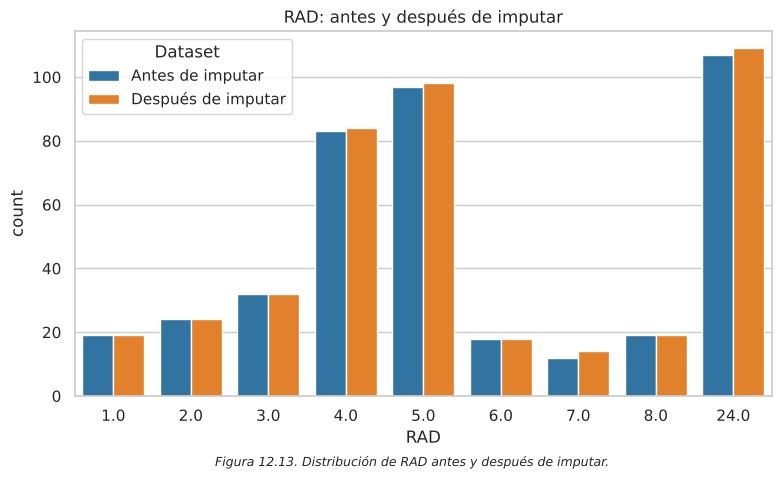

In [49]:
# Categóricas: conteo por categoría antes y después de imputar, numerado a continuación de los histogramas
columnas_categoricas = [c for c in comparacion.columns.drop('Dataset') if c not in columnas_continuas]
for i, col in enumerate(columnas_categoricas, start=len(columnas_continuas) + 1):
    plt.figure(figsize=(9, 5))
    sns.countplot(data=comparacion, x=col, hue='Dataset', palette='tab10')
    plt.title(f'{col}: antes y después de imputar')
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(0.5, 0.01, f'Figura 12.{i}. Distribución de {col} antes y después de imputar.',
                ha='center', fontsize=9, style='italic')
    plt.show()

Las distribuciones casi no cambian al imputar. KNN completa con promedios de vecinos, así que los valores nuevos caen dentro del rango observado de cada variable. En CHAS y RAD, CatBoost solo asigna categorías válidas, y la proporción de 0 y 1 en CHAS se mantiene casi igual (Figura 12.12).

## Resumen del preprocesamiento

Sacamos las filas sin `MEDV` y las que tenían más de la mitad de los valores faltantes, y marcamos como nulos los valores inválidos de `RAD`. Revisamos los outliers con IQR y los cruzamos con la matriz de correlación para decidir cuáles eran incoherentes. Recién ahí separamos train y test, eliminamos de train (nunca de test) las filas trianguladas, y escalamos con `RobustScaler`. Por último imputamos las continuas con `KNNImputer` (el `k` salió del método del codo) y `RAD` y `CHAS` con `CatBoostClassifier`.

# Modelado

Entrenamos una **regresión lineal**, que estima `MEDV` como una suma ponderada de las variables, de dos formas: con `scikit-learn` y con las funciones de descenso del gradiente del material de clase.

## Regresión lineal con scikit-learn

`LinearRegression` sobre `X_train_imp`, evaluada con MAE, RMSE y R² en train y test. MAE y RMSE quedan en miles de dólares, como `MEDV`.

In [50]:
# Regresión lineal por mínimos cuadrados, y la función de métricas que usamos en todo el notebook
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_imp, y_train)

pred_train_sk = modelo_lineal.predict(X_train_imp)
pred_test_sk = modelo_lineal.predict(X_test_imp)


def metricas(y_real, y_pred):
    return {
        'MAE': mean_absolute_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'R2': r2_score(y_real, y_pred),
    }


metricas_sk = {'Train': metricas(y_train, pred_train_sk), 'Test': metricas(y_test, pred_test_sk)}
pd.DataFrame(metricas_sk).T.round(4)

,MAE,RMSE,R2
Train,3.7005,5.7154,0.6113
Test,4.2010,6.4267,0.6174


In [51]:
# Coeficientes en la escala de X_train_imp (continuas escaladas con RobustScaler)
print(f'Intercepto: {modelo_lineal.intercept_:.4f}')

coeficientes_sk = pd.Series(modelo_lineal.coef_, index=X_train_imp.columns)
coeficientes_sk.sort_values().round(4)

Intercepto: 22.1959


LSTAT     -4.3599
DIS       -3.5160
AGE       -2.8003
PTRATIO   -2.6829
TAX       -2.2760
INDUS     -0.4300
NOX       -0.1377
CRIM       0.0214
RAD        0.0738
B          0.2276
ZN         0.6522
RM         2.6648
CHAS       4.9313
dtype: float64

## Descenso del gradiente

El **descenso del gradiente** arranca con pesos al azar y los corrige paso a paso en la dirección que más reduce el error cuadrático medio. Usamos las funciones del material de clase, con tres variantes:

| Variante | Cuándo actualiza los pesos |
|---|---|
| Batch | una vez por época, con el gradiente de todo el conjunto |
| Estocástico (SGD) | una vez por muestra |
| Mini-batch | una vez por lote de muestras |

Todas usan `y_pred = X @ W`, con una columna de unos para el término independiente, y actualizan con `W = W - lr · gradiente`. Las tres corren un número fijo de épocas, sin criterio de corte. Devuelven solo los pesos `W` y grafican adentro el error de train y de test.

`RAD` (hasta 24) y `CHAS` (0 o 1) no pasaron por `RobustScaler`, y con escalas tan mezcladas una sola tasa no sirve para todas las variables. Por eso estandarizamos para entrenar y después devolvemos los pesos a la escala original, para compararlos con `LinearRegression`.

In [52]:
# Estandarizamos solo para el descenso del gradiente; y pasa a vector columna
from sklearn.preprocessing import StandardScaler

escalador_gd = StandardScaler()
X_train_gd = escalador_gd.fit_transform(X_train_imp)
X_test_gd = escalador_gd.transform(X_test_imp)

y_train_gd = y_train.to_numpy(dtype=float).reshape(-1, 1)
y_test_gd = y_test.to_numpy(dtype=float).reshape(-1, 1)

### Variante 1: batch

Un gradiente por época con las 417 filas de train. Es la más estable y tolera la tasa más alta, pero cada paso recorre todo el dataset.

In [53]:
# Descenso del gradiente batch (función del material de clase, copiada sin cambios)
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    La función ajusta los pesos W de un modelo lineal de la forma:
        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Parámetros
    ----------
    X_train :
      np.ndarray Matriz de características de entrenamiento de dimensiones (n, m), donde n es la cantidad de muestras y m la cantidad de variables.
    y_train :
      np.ndarray Vector de valores objetivo de entrenamiento de dimensiones (n, 1).
    X_val :
      np.ndarray Matriz de características de validación de dimensiones (p, m), donde p es la cantidad de muestras de validación.
    y_val :
      np.ndarray Vector de valores objetivo de validación de dimensiones (p, 1).
    lr :
      float, optional Tasa de aprendizaje utilizada para actualizar los pesos. Por defecto es 0.01.
    epochs :
      int, optional Cantidad de iteraciones del algoritmo de Gradient Descent. Por defecto es 100.

    Retorna
    -------
    np.ndarray Vector de pesos W de dimensiones (m + 1, 1), incluyendo el término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_val para representar el término independiente (bias).
    2. Se inicializan aleatoriamente los pesos W.
    3. En cada época:
      - Se calcula la predicción sobre el conjunto de entrenamiento.
      - Se calcula el MSE de entrenamiento.
      - Se calcula la predicción sobre el conjunto de validación.
      - Se calcula el MSE de validación.
      - Se calcula el gradiente de la función de costo respecto de W.
      - Se actualizan los pesos utilizando la regla de Gradient Descent: W = W - lr * gradient
      4. Finalmente, se grafica la evolución del MSE de entrenamiento y validación a lo largo de las épocas.
        El gradiente utilizado corresponde a: ∇J(W) = -(2 / n) X.T (y - XW) donde J(W) es el Error Cuadrático Medio.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

### Variante 2: estocástico (SGD)

Actualiza con cada muestra, 417 veces por época. Avanza rápido pero con ruido, y necesita una tasa mucho más chica.

In [54]:
# Descenso del gradiente estocástico (función del material de clase, copiada sin cambios)
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Stochastic Gradient Descent (SGD).

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    A diferencia de Gradient Descent tradicional, que calcula el gradiente
    utilizando todas las muestras antes de actualizar los pesos, SGD actualiza
    los pesos después de procesar cada muestra individual.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todas las muestras de entrenamiento. Por defecto es 100.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se permutan aleatoriamente las muestras de entrenamiento
      para evitar que el orden de los datos afecte al proceso de aprendizaje.

    4. Para cada muestra de entrenamiento:
      - Se calcula la predicción.
      - Se calcula el error entre el valor real y la predicción.
      - Se calcula el error cuadrático de esa muestra.
      - Se calcula el gradiente respecto de los pesos.
      - Se actualizan inmediatamente los pesos.

    5. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para observar la evolución del modelo.

    El gradiente utilizado para una muestra individual es:

        ∇J(W) = -2 * x_i.T * (y_i - x_i @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de Gradient Descent tradicional es que
    el gradiente se calcula y los pesos se actualizan utilizando una sola
    muestra por vez, en lugar de utilizar todo el conjunto de entrenamiento.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

### Variante 3: mini-batch

Gradiente sobre lotes de 64 filas: menos ruido que el estocástico, sin el costo de recorrer todo el dataset en cada paso. La función divide el gradiente por `batch_size` también en el último lote, que tiene 33 filas, así que ese paso queda algo más corto.

In [55]:
# Descenso del gradiente mini-batch (función del material de clase, copiada sin cambios)
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    """
    Entrena un modelo de regresión lineal mediante Mini-Batch Gradient Descent.

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Mini-Batch Gradient Descent combina las características de Gradient Descent
    tradicional y Stochastic Gradient Descent (SGD): en lugar de calcular el
    gradiente utilizando todo el conjunto de entrenamiento o una única muestra,
    calcula el gradiente utilizando pequeños lotes (mini-batches) de datos.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todos los mini-batches del conjunto de entrenamiento.
        Por defecto es 100.

    batch_size : int, optional
        Cantidad de muestras utilizadas para calcular cada actualización
        de los pesos. Por defecto es 11.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se realiza una permutación aleatoria de las muestras
      de entrenamiento para evitar que el orden de los datos influya
      sistemáticamente en el aprendizaje.

    4. El conjunto de entrenamiento se divide en mini-batches de tamaño
      batch_size.

    5. Para cada mini-batch:
      - Se calcula la predicción:

            y_pred = X_batch @ W

      - Se calcula el error:

            error = y_batch - y_pred

      - Se calcula el MSE del mini-batch.
      - Se calcula el gradiente utilizando todas las muestras del
        mini-batch.
      - Se actualizan inmediatamente los pesos.

    6. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para evaluar la evolución del modelo.

    El gradiente utilizado es:

        ∇J(W) = -(2 / batch_size) * X_batch.T @ (y_batch - X_batch @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de los otros métodos es el tamaño
    del conjunto utilizado para cada actualización:

        Gradient Descent:
            utiliza todas las muestras.

        Stochastic Gradient Descent:
            utiliza una única muestra.

        Mini-Batch Gradient Descent:
            utiliza un pequeño grupo de muestras.

    Por lo tanto, Mini-Batch Gradient Descent busca un equilibrio entre
    la estabilidad del gradiente calculado sobre todo el dataset y la
    velocidad y frecuencia de actualización característica de SGD.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

### Entrenamiento de las tres variantes

Cada variante usa su propia tasa. Por época, el batch actualiza los pesos una vez, el mini-batch 7 veces y el estocástico 417. Cuantas más actualizaciones, más chica tiene que ser la tasa para no oscilar.

Las funciones usan el generador global de NumPy, así que fijamos `np.random.seed(42)` antes de cada llamada. Como devuelven solo `W`, armamos un ayudante que copia los datos de cada gráfico antes de mostrarlo. Con eso juntamos las tres curvas en la Figura 13 sin modificar las funciones. Las métricas finales las calculamos a partir de `W`.

In [56]:
# Las funciones devuelven solo W y grafican el error adentro.
# Este ayudante copia los datos de cada curva antes de mostrar el gráfico, sin tocar las funciones.
def entrenar_registrando(funcion, *args, mostrar=True, pie=None, **kwargs):
    curvas = {}
    mostrar_original = plt.show

    def capturar(*a, **k):
        for linea in plt.gca().get_lines():
            curvas[linea.get_label()] = np.asarray(linea.get_ydata(), dtype=float).ravel()
        if pie:
            plt.subplots_adjust(bottom=0.15)
            plt.figtext(0.5, 0.01, pie, ha='center', fontsize=9, style='italic')
        if mostrar:
            mostrar_original(*a, **k)
        else:
            plt.close()

    plt.show = capturar
    try:
        W = funcion(*args, **kwargs)
    finally:
        plt.show = mostrar_original
    return W, curvas


# MSE sobre un conjunto completo, a partir de los pesos aprendidos
def mse_final(W, X, y):
    X_con_unos = np.hstack((np.ones((X.shape[0], 1)), X))
    return float(np.mean((y - X_con_unos @ W) ** 2))


# SGD y mini-batch registran el error en cada actualización: tomamos el último registro de cada época
def por_epoca(curva, actualizaciones_por_epoca):
    return curva[actualizaciones_por_epoca - 1::actualizaciones_por_epoca]


# Primera época desde la cual la curva queda a menos del 1% de su valor final
def epoca_estable(curva, tolerancia_relativa=0.01):
    fuera = np.abs(curva - curva[-1]) / curva[-1] >= tolerancia_relativa
    return int(np.nonzero(fuera)[0].max()) + 2 if fuera.any() else 1

In [57]:
# Entrenamos las tres variantes, cada una con su tasa y la misma semilla
n_train = len(X_train_gd)
config_gd = {
    'Batch': (gradient_descent, dict(lr=0.1, epochs=3000)),
    'Estocástico': (stochastic_gradient_descent, dict(lr=0.0005, epochs=100)),
    'Mini-batch': (mini_batch_gradient_descent, dict(lr=0.01, epochs=300, batch_size=64)),
}

pesos_gd, curvas_gd = {}, {}
for nombre, (funcion, params) in config_gd.items():
    np.random.seed(42)
    # Las curvas por variante se muestran después, juntas en la Figura 13
    pesos_gd[nombre], curvas_gd[nombre] = entrenar_registrando(
        funcion, X_train_gd, y_train_gd, X_test_gd, y_test_gd, mostrar=False, **params
    )

W_batch, W_sgd, W_mb = pesos_gd['Batch'], pesos_gd['Estocástico'], pesos_gd['Mini-batch']

for nombre, (_, params) in config_gd.items():
    W = pesos_gd[nombre]
    actualizaciones = len(curvas_gd[nombre]['Error de entrenamiento'])
    print(f"{nombre:<13} épocas: {params['epochs']:>4} | actualizaciones: {actualizaciones:>6} | "
          f"MSE final en train: {mse_final(W, X_train_gd, y_train_gd):.4f} | "
          f"MSE final en test: {mse_final(W, X_test_gd, y_test_gd):.4f}")

Batch         épocas: 3000 | actualizaciones:   3000 | MSE final en train: 32.6660 | MSE final en test: 41.3026
Estocástico   épocas:  100 | actualizaciones:  41700 | MSE final en train: 32.6796 | MSE final en test: 41.4420
Mini-batch    épocas:  300 | actualizaciones:   2100 | MSE final en train: 32.6661 | MSE final en test: 41.2723


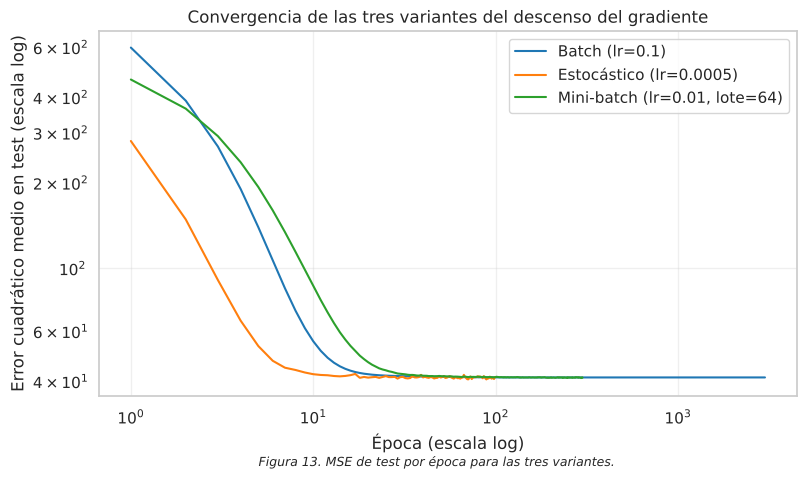

Batch         MSE de test a menos del 1% del final desde la época 32 de 3000
Estocástico   MSE de test a menos del 1% del final desde la época 99 de 100
Mini-batch    MSE de test a menos del 1% del final desde la época 57 de 300


In [58]:
# Curvas de convergencia en escala log: MSE de test al cerrar cada época
actualizaciones_por_epoca = {'Batch': 1, 'Estocástico': n_train, 'Mini-batch': int(np.ceil(n_train / 64))}
nombre_curva_test = {'Batch': 'Error de validación', 'Estocástico': 'Error de prueba', 'Mini-batch': 'Error de prueba'}
etiquetas = {'Batch': 'Batch (lr=0.1)', 'Estocástico': 'Estocástico (lr=0.0005)',
             'Mini-batch': 'Mini-batch (lr=0.01, lote=64)'}

plt.figure(figsize=(9, 5))
for nombre in config_gd:
    curva = por_epoca(curvas_gd[nombre][nombre_curva_test[nombre]], actualizaciones_por_epoca[nombre])
    plt.plot(np.arange(1, len(curva) + 1), curva, label=etiquetas[nombre])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Época (escala log)')
plt.ylabel('Error cuadrático medio en test (escala log)')
plt.title('Convergencia de las tres variantes del descenso del gradiente')
plt.legend()
plt.grid(alpha=0.3)
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 13. MSE de test por época para las tres variantes.',
            ha='center', fontsize=9, style='italic')
plt.show()

for nombre in config_gd:
    curva = por_epoca(curvas_gd[nombre][nombre_curva_test[nombre]], actualizaciones_por_epoca[nombre])
    print(f'{nombre:<13} MSE de test a menos del 1% del final desde la época {epoca_estable(curva)} de {len(curva)}')

La Figura 13 muestra el MSE de test porque es la única curva que las tres funciones miden sobre un conjunto completo: en estocástico y mini-batch, el error de train de cada paso corresponde a una sola muestra o a un lote. El error de test lo usamos solo para mirar la convergencia y no interviene en el entrenamiento. El eje de épocas va en escala log porque el batch corre 3000 épocas y el estocástico 100.

In [59]:
# Los pesos se aprendieron sobre features estandarizadas: los devolvemos a la escala original
def recuperar_parametros(W):
    coeficientes = W[1:, 0] / escalador_gd.scale_
    intercepto = W[0, 0] - np.sum(W[1:, 0] * escalador_gd.mean_ / escalador_gd.scale_)
    return coeficientes, intercepto


resultados_gd = {}
for nombre, W in [('Batch', W_batch), ('Estocástico', W_sgd), ('Mini-batch', W_mb)]:
    coeficientes, intercepto = recuperar_parametros(W)
    resultados_gd[nombre] = {
        'coeficientes': coeficientes,
        'intercepto': intercepto,
        'Train': metricas(y_train, X_train_imp @ coeficientes + intercepto),
        'Test': metricas(y_test, X_test_imp @ coeficientes + intercepto),
    }
    print(f'{nombre:<13} intercepto: {intercepto:.4f}')

Batch         intercepto: 22.1959
Estocástico   intercepto: 22.2519
Mini-batch    intercepto: 22.1903


### Gráficas de error vs iteraciones con los parámetros de clase

La consigna del trabajo pide *"incorporar gráficas de Error vs Iteraciones (loss vs epochs)"*, que muestran si la **función de costo** converge, oscila o diverge. Corremos las mismas funciones con los parámetros del material de clase: 200 épocas, `lr=0.01` y lote de 11. Debajo de cada gráfico imprimimos el MSE final en train y en test.

En batch, la curva de *validación* es en realidad test (así la llama la función) y cada punto es una época; en estocástico y mini-batch, cada punto es una actualización.

#### Batch

Una actualización por época sobre todo el conjunto, así que las curvas deberían bajar suaves.

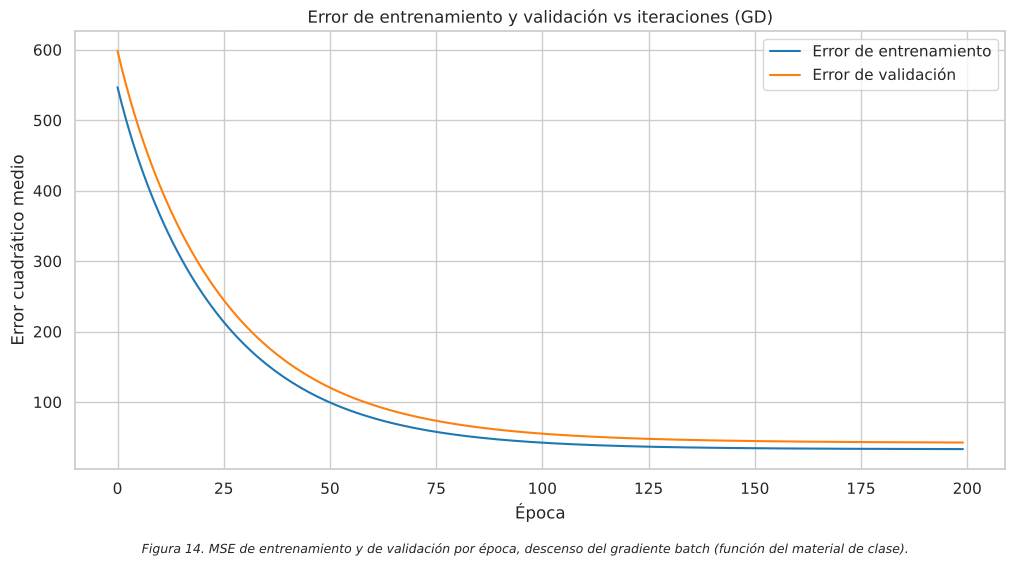

MSE final en train: 33.20 | MSE final en test: 42.50


In [60]:
# Parámetros por defecto del material de clase, sobre los datos estandarizados
np.random.seed(42)
W_catedra_gd, _ = entrenar_registrando(
    gradient_descent, X_train_gd, y_train_gd, X_test_gd, y_test_gd, epochs=200, lr=0.01,
    pie='Figura 14. MSE de entrenamiento y de validación por época, descenso del gradiente batch (función del material de clase).'
)
print(f'MSE final en train: {mse_final(W_catedra_gd, X_train_gd, y_train_gd):.2f} | '
      f'MSE final en test: {mse_final(W_catedra_gd, X_test_gd, y_test_gd):.2f}')

#### Estocástico (SGD)

Unas 83.400 actualizaciones en total. La curva de train mide una sola muestra por vez y es ruidosa por construcción; conviene mirar la de test.

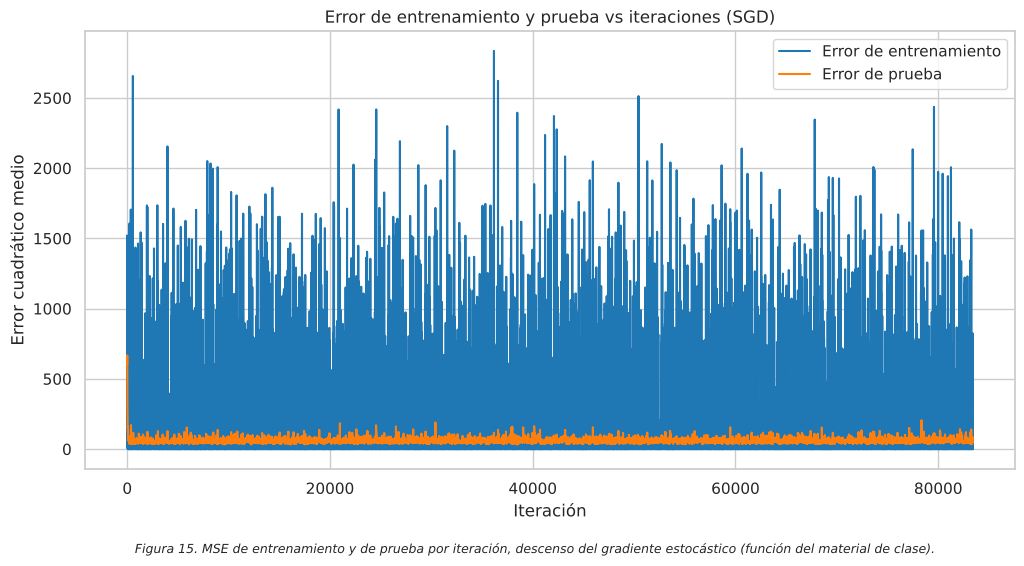

MSE final en train: 43.26 | MSE final en test: 80.65


In [61]:
# Parámetros por defecto del material de clase, sobre los datos estandarizados
np.random.seed(42)
W_catedra_sgd, _ = entrenar_registrando(
    stochastic_gradient_descent, X_train_gd, y_train_gd, X_test_gd, y_test_gd, epochs=200, lr=0.01,
    pie='Figura 15. MSE de entrenamiento y de prueba por iteración, descenso del gradiente estocástico (función del material de clase).'
)
print(f'MSE final en train: {mse_final(W_catedra_sgd, X_train_gd, y_train_gd):.2f} | '
      f'MSE final en test: {mse_final(W_catedra_sgd, X_test_gd, y_test_gd):.2f}')

#### Mini-batch

38 lotes de 11 por época: oscila menos que el estocástico y más que el batch.

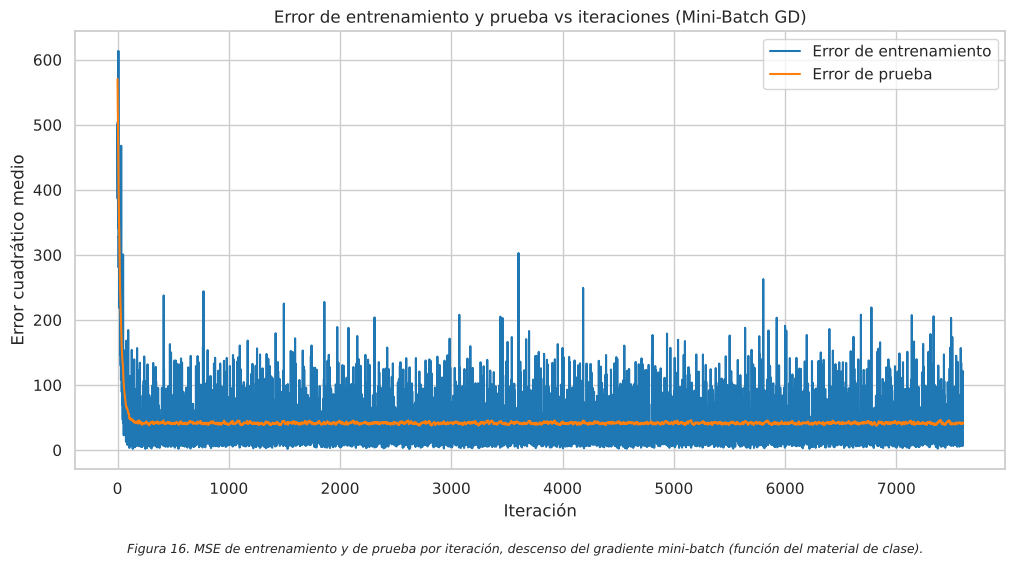

MSE final en train: 32.71 | MSE final en test: 42.08


In [62]:
# Parámetros por defecto del material de clase, sobre los datos estandarizados
np.random.seed(42)
W_catedra_mb, _ = entrenar_registrando(
    mini_batch_gradient_descent, X_train_gd, y_train_gd, X_test_gd, y_test_gd, epochs=200, lr=0.01,
    pie='Figura 16. MSE de entrenamiento y de prueba por iteración, descenso del gradiente mini-batch (función del material de clase).'
)
print(f'MSE final en train: {mse_final(W_catedra_mb, X_train_gd, y_train_gd):.2f} | '
      f'MSE final en test: {mse_final(W_catedra_mb, X_test_gd, y_test_gd):.2f}')

#### ¿Algún cambio?

Sí. Con `lr=0.01` el batch baja suave pero no llega al mínimo en 200 épocas: termina con un MSE de 33.20 en train, contra 32.67 del batch con `lr=0.1`. El mini-batch con lote de 11 converge (32.71 en train). El estocástico oscila sin asentarse y termina en 43.26 en train y 80.65 en test; por eso en el entrenamiento principal le dimos una tasa mucho menor (0.0005). Cuantas más actualizaciones por época, más chica tiene que ser la **tasa de aprendizaje**.

## Comparación de los métodos

In [63]:
# Coeficientes en escala original de los cuatro métodos
comparacion_coeficientes = pd.DataFrame(
    {'LinearRegression': modelo_lineal.coef_,
     **{f'GD {nombre}': r['coeficientes'] for nombre, r in resultados_gd.items()}},
    index=X_train_imp.columns,
)
comparacion_coeficientes.round(4)

,LinearRegression,GD Batch,GD Estocástico,GD Mini-batch
CRIM,0.0214,0.0214,0.0112,0.0229
ZN,0.6522,0.6522,0.6514,0.6538
INDUS,-0.4300,-0.4300,-0.4391,-0.4165
CHAS,4.9313,4.9313,4.7455,4.9456
NOX,-0.1377,-0.1377,-0.1533,-0.1329
RM,2.6648,2.6648,2.6881,2.6665
AGE,-2.8003,-2.8003,-2.8151,-2.8034
DIS,-3.5160,-3.5160,-3.5251,-3.5173
RAD,0.0738,0.0738,0.0717,0.0742
TAX,-2.2760,-2.2760,-2.3441,-2.2836


In [64]:
# Métricas en train y test de los cuatro métodos
comparacion_metricas = pd.DataFrame({
    ('LinearRegression', 'Train'): metricas_sk['Train'],
    ('LinearRegression', 'Test'): metricas_sk['Test'],
    **{(f'GD {nombre}', particion): r[particion]
       for nombre, r in resultados_gd.items()
       for particion in ['Train', 'Test']},
}).T
comparacion_metricas.round(4)

MAE   RMSE     R2
LinearRegression Train 3.7005 5.7154 0.6113
                 Test  4.2010 6.4267 0.6174
GD Batch         Train 3.7005 5.7154 0.6113
                 Test  4.2010 6.4267 0.6174
GD Estocástico   Train 3.6880 5.7166 0.6111
                 Test  4.2127 6.4375 0.6161
GD Mini-batch    Train 3.7018 5.7154 0.6113
                 Test  4.1995 6.4244 0.6177

### Lectura de la comparación

Los cuatro métodos llegan casi a la misma solución porque el costo de la regresión lineal es **convexo** y tiene un único mínimo. El batch coincide con `LinearRegression` en los cuatro decimales de la tabla. El mini-batch se aparta como mucho en 0.014 y el estocástico en 0.19, los dos en `CHAS`: oscilan alrededor del mínimo y se quedan donde cae el último paso.

En la Figura 13, el MSE de test del batch queda a menos del 1% de su valor final desde la época 32, y el del mini-batch desde la 57. El estocástico baja más rápido por época, porque hace 417 actualizaciones en cada una, pero sigue oscilando hasta la última. La función batch no tiene criterio de corte y recorre las 3000 épocas, aunque con la misma tasa llega a 1% del MSE de `LinearRegression` en la época 24 (barrido de la Figura 17). Con 417 filas el costo computacional no pesa: el descenso del gradiente se vuelve necesario cuando el volumen de datos hace inviable la solución analítica.

## Regularización: Ridge, Lasso y ElasticNet

La **regularización** le suma al error un castigo por el tamaño de los coeficientes, para frenar el sobreajuste: Ridge usa sus cuadrados (L2), Lasso sus valores absolutos (L1) y ElasticNet ambos. Como vimos en clase, cada modelo va en un pipeline con `StandardScaler` y la versión `CV` elige `alpha` por validación cruzada en train. Sacamos `l1_ratio=0` de ElasticNet porque equivale a Ridge y no converge bien.

Escalar es obligatorio: sin eso, el castigo dependería de las unidades de cada variable.

`RidgeCV` usa por defecto validación *leave-one-out*, que es rápida para Ridge. Lasso y ElasticNet usan 5 y 10 folds.

In [65]:
# Cada modelo en un pipeline con StandardScaler; la versión CV elige alpha por validación cruzada
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

modelos_reg = {
    'Ridge': make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 6, 200))),
    'Lasso': make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 2, 200), cv=5)),
    'ElasticNet': make_pipeline(StandardScaler(), ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99], alphas=np.logspace(-3, 6, 200), cv=10)),
}

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_imp, y_train)
    extra = f' | l1_ratio: {modelo[-1].l1_ratio_}' if nombre == 'ElasticNet' else ''
    print(f'{nombre:<11} alpha elegido: {modelo[-1].alpha_:.4g}{extra}')

Ridge       alpha elegido: 67.48
Lasso       alpha elegido: 0.111


ElasticNet  alpha elegido: 0.1482 | l1_ratio: 0.5


Coeficientes en escala estandarizada: se comparan entre sí, pero no con los de la regresión lineal. Los ceros de Lasso son variables descartadas.

In [66]:
# Coeficientes de los modelos regularizados (escala estandarizada)
pd.DataFrame(
    {nombre: modelo[-1].coef_ for nombre, modelo in modelos_reg.items()},
    index=X_train_imp.columns,
).round(4)

,Ridge,Lasso,ElasticNet
CRIM,-0.1887,-0.0000,-0.0775
ZN,0.5818,0.5748,0.5467
INDUS,-0.3153,-0.1844,-0.2472
CHAS,1.1827,1.1868,1.1726
NOX,-0.0911,-0.0000,-0.0000
RM,2.3984,2.5212,2.4699
AGE,-1.0108,-1.2267,-1.0769
DIS,-1.4558,-1.8180,-1.5509
RAD,0.1900,0.0000,0.0000
TAX,-0.5851,-0.3462,-0.4183


### Métricas en train y test

MAE y RMSE están en miles de dólares, como `MEDV` (el RMSE castiga más los errores grandes), y R² es la proporción de la variabilidad del precio que explica el modelo. Descartamos el MSE, que es el RMSE al cuadrado, y el MAPE, que se infla en las casas baratas.

In [67]:
# Métricas en train y test de la regresión lineal y los regularizados
comparacion_reg = {('LinearRegression', p): metricas_sk[p] for p in ['Train', 'Test']}
for nombre, modelo in modelos_reg.items():
    comparacion_reg[(nombre, 'Train')] = metricas(y_train, modelo.predict(X_train_imp))
    comparacion_reg[(nombre, 'Test')] = metricas(y_test, modelo.predict(X_test_imp))

pd.DataFrame(comparacion_reg).T.round(4)

MAE   RMSE     R2
LinearRegression Train 3.7005 5.7154 0.6113
                 Test  4.2010 6.4267 0.6174
Ridge            Train 3.7545 5.7791 0.6026
                 Test  4.2078 6.5089 0.6076
Lasso            Train 3.7235 5.7393 0.6080
                 Test  4.2354 6.4793 0.6112
ElasticNet       Train 3.7439 5.7602 0.6052
                 Test  4.2167 6.4774 0.6114

### ¿Por qué medir en ambos conjuntos?

Train dice qué tan bien el modelo ajusta lo que ya vio; test, qué tan bien predice datos nuevos. Compararlos es el diagnóstico de **sobreajuste y subajuste**:

| Train | Test | Diagnóstico |
|---|---|---|
| bueno | mucho peor | sobreajuste (overfitting) |
| malo | malo | subajuste (underfitting) |
| bueno | parecido | buen ajuste |

### ¿Conseguimos un buen fitting?

No hay sobreajuste: train y test dan casi igual (R² de 0.61 y 0.62 en la regresión lineal). Por eso regularizar no mejora las métricas. Lasso sí simplifica el modelo: anula `CRIM`, `NOX` y `RAD` (celda de coeficientes regularizados).

Sí hay algo de subajuste: el modelo deja sin explicar cerca del 40% de la variabilidad y en test erra entre 4.200 dólares (MAE) y 6.400 (RMSE). Una causa posible son relaciones no lineales; otra, el techo de 50 en `MEDV` (Figura 1). No lo comprobamos con un gráfico de residuos, así que queda como hipótesis. Para mejorar probaríamos términos polinómicos o interacciones; más regularización no ayudaría.

# Optimización de hiperparámetros

Los **hiperparámetros** (tasa de aprendizaje, tamaño de lote, `alpha`) se fijan antes de entrenar. Variamos uno por vez, con el resto fijo.

## Descenso del gradiente: tasa de aprendizaje

Como vimos en clase, probamos varias `lr` en el batch. El límite de convergencia se calcula: 2 dividido el autovalor más grande de `2/n · XᵀX`. Probamos tres valores chicos y dos pegados al límite, uno de cada lado.

lr máximo para que el batch converja: 0.176
lr = 0.001  | MSE final: 182.99 | no llega a 1% del MSE de LinearRegression
lr = 0.01   | MSE final: 32.82 | a 1% del MSE de LinearRegression en la época 233
lr = 0.1    | MSE final: 32.67 | a 1% del MSE de LinearRegression en la época 24
lr = 0.167  | MSE final: 32.67 | a 1% del MSE de LinearRegression en la época 22
lr = 0.185  | diverge | no llega a 1% del MSE de LinearRegression


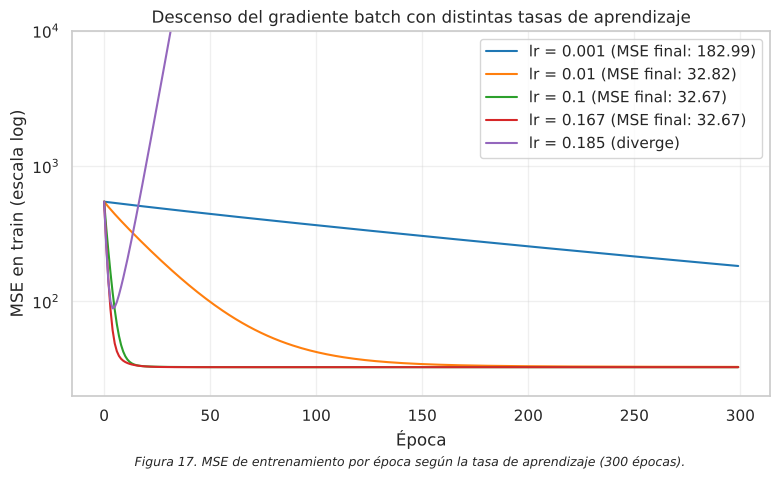

In [68]:
# Límite teórico de lr para el batch y barrido de tasas alrededor de él
X_con_unos = np.hstack((np.ones((len(X_train_gd), 1)), X_train_gd))
lr_max = 2 / np.linalg.eigvalsh(2 / len(X_con_unos) * X_con_unos.T @ X_con_unos).max()
print(f'lr máximo para que el batch converja: {lr_max:.3f}')
mse_referencia = metricas_sk['Train']['RMSE'] ** 2  # mínimo exacto, el de LinearRegression

plt.figure(figsize=(9, 5))
for lr in [0.001, 0.01, 0.1, round(0.95 * lr_max, 3), round(1.05 * lr_max, 3)]:
    np.random.seed(42)
    with np.errstate(over='ignore', invalid='ignore'):
        _, curvas = entrenar_registrando(gradient_descent, X_train_gd, y_train_gd, X_test_gd, y_test_gd,
                                         lr=lr, epochs=300, mostrar=False)
    err_train = curvas['Error de entrenamiento']
    final = f'MSE final: {err_train[-1]:.2f}' if err_train[-1] < 1e4 else 'diverge'
    cerca = np.nonzero(err_train <= 1.01 * mse_referencia)[0]
    llegada = f'a 1% del MSE de LinearRegression en la época {cerca[0] + 1}' if len(cerca) else 'no llega a 1% del MSE de LinearRegression'
    print(f'lr = {lr:<6} | {final} | {llegada}')
    plt.plot(err_train, label=f'lr = {lr} ({final})')
plt.yscale('log')
plt.ylim(20, 1e4)
plt.xlabel('Época')
plt.ylabel('MSE en train (escala log)')
plt.title('Descenso del gradiente batch con distintas tasas de aprendizaje')
plt.legend()
plt.grid(alpha=0.3)
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 17. MSE de entrenamiento por época según la tasa de aprendizaje (300 épocas).',
            ha='center', fontsize=9, style='italic')
plt.show()

**¿Qué observamos?** Con `lr` chico converge lento: con 0.001 no llega en 300 épocas (MSE final de 182.99) y con 0.01 tarda 233 épocas en quedar a 1% del MSE de `LinearRegression`. Con 0.1 llega en 24 épocas y con 0.167, pegado al límite de 0.176, en 22. Pasado el límite, con 0.185, cada paso saltea el mínimo y el error explota. La mejor tasa es la más grande que todavía converge.

## Descenso del gradiente: tamaño del lote

Con `lr=0.01` y 100 épocas fijas variamos el lote. Un lote de 1 es el estocástico; uno de todo train, el batch. La Figura 18 muestra el MSE de test, que la función mide sobre todo el conjunto después de cada actualización.

lote    1 | MSE train: 39.36 | MSE test: 63.31
lote    8 | MSE train: 32.89 | MSE test: 42.91
lote   32 | MSE train: 32.67 | MSE test: 41.31
lote  128 | MSE train: 32.79 | MSE test: 41.69
lote  417 | MSE train: 42.31 | MSE test: 55.10


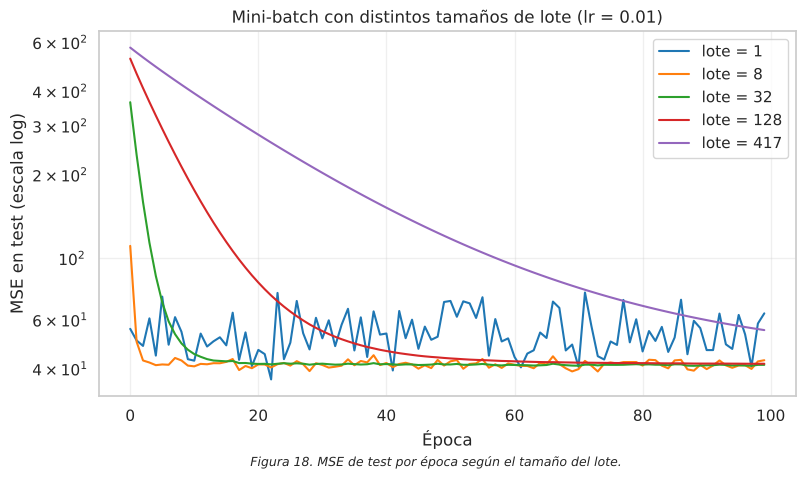

In [69]:
# Mismo lr, distintos tamaños de lote
tamanos_lote = [1, 8, 32, 128, len(X_train_gd)]

plt.figure(figsize=(9, 5))
for tamano in tamanos_lote:
    np.random.seed(42)
    W_lote, curvas = entrenar_registrando(mini_batch_gradient_descent, X_train_gd, y_train_gd, X_test_gd, y_test_gd,
                                          lr=0.01, epochs=100, batch_size=tamano, mostrar=False)
    err_test = por_epoca(curvas['Error de prueba'], int(np.ceil(len(X_train_gd) / tamano)))
    plt.plot(err_test, label=f'lote = {tamano}')
    print(f'lote {tamano:>4} | MSE train: {mse_final(W_lote, X_train_gd, y_train_gd):.2f} | '
          f'MSE test: {mse_final(W_lote, X_test_gd, y_test_gd):.2f}')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('MSE en test (escala log)')
plt.title('Mini-batch con distintos tamaños de lote (lr = 0.01)')
plt.legend()
plt.grid(alpha=0.3)
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 18. MSE de test por época según el tamaño del lote.',
            ha='center', fontsize=9, style='italic')
plt.show()

**¿Qué observamos?** Los lotes chicos actualizan más veces por época y bajan más rápido. El lote completo no converge en 100 épocas y termina con un MSE de 55.10 en test. El lote de 1 es tan ruidoso que rebota alrededor del mínimo y termina en 63.31, peor que el lote completo. Los intermedios equilibran ambos extremos: el de 32 termina en 41.31, el mejor del barrido. Por eso el mini-batch es el más usado. Con lotes más chicos conviene bajar la tasa.

## Ridge y Lasso: variación de alpha

Recorremos `alpha` en escala logarítmica, como en el material de clase. La línea punteada es el `alpha` elegido por validación cruzada.

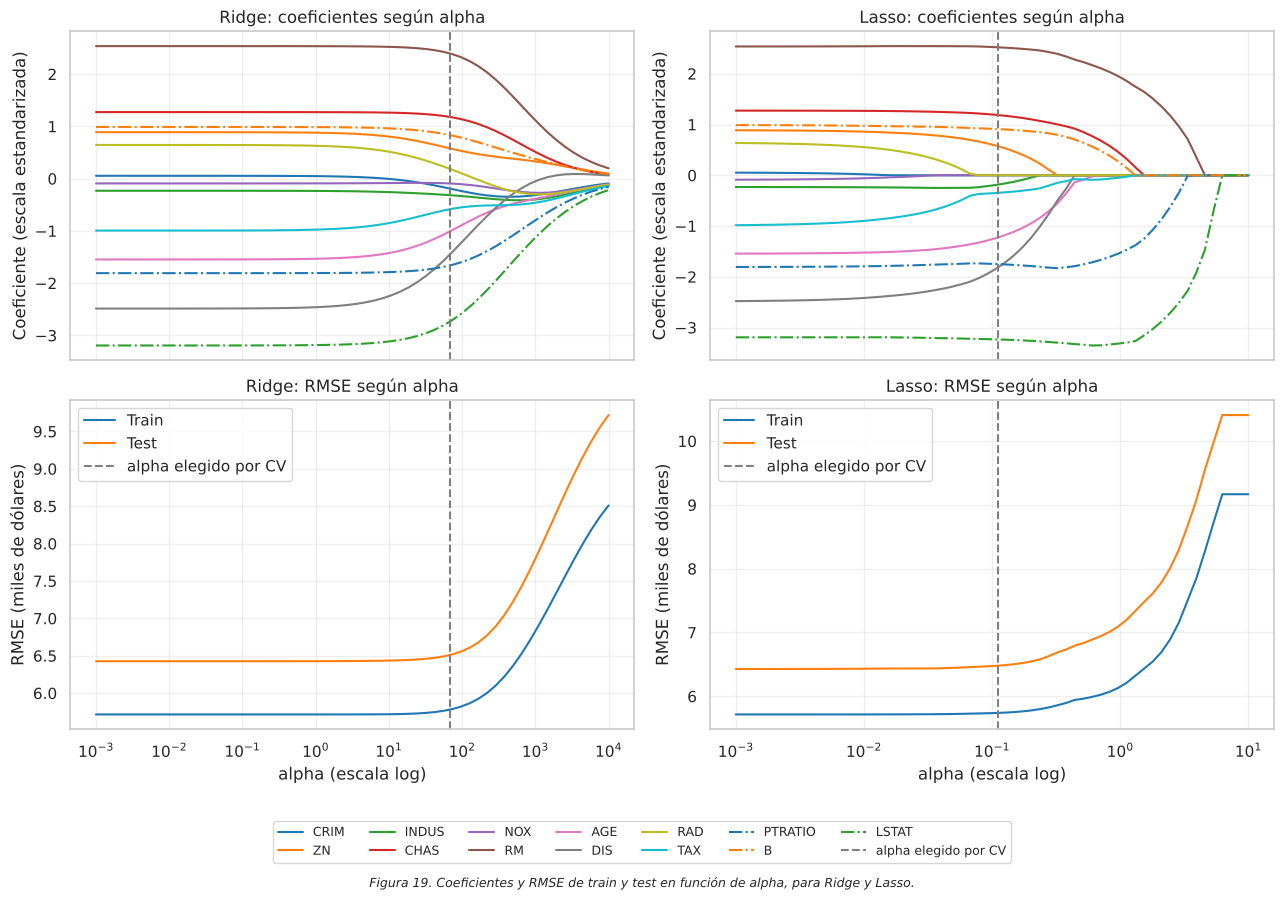

In [70]:
# Barrido de alpha: coeficientes y RMSE para Ridge y Lasso
from sklearn.linear_model import Ridge, Lasso

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex='col')
for col, (nombre, Modelo, alphas) in enumerate([('Ridge', Ridge, np.logspace(-3, 4, 60)),
                                                ('Lasso', Lasso, np.logspace(-3, 1, 60))]):
    coefs, rmse_train, rmse_test = [], [], []
    for alpha in alphas:
        modelo = make_pipeline(StandardScaler(), Modelo(alpha=alpha)).fit(X_train_imp, y_train)
        coefs.append(modelo[-1].coef_)
        rmse_train.append(metricas(y_train, modelo.predict(X_train_imp))['RMSE'])
        rmse_test.append(metricas(y_test, modelo.predict(X_test_imp))['RMSE'])

    lineas = axes[0, col].plot(alphas, coefs)
    for linea in lineas[10:]:
        linea.set_linestyle('-.')  # la paleta tiene 10 colores: desde la línea 11 cambia el trazo
    axes[0, col].set_title(f'{nombre}: coeficientes según alpha')
    axes[0, col].set_ylabel('Coeficiente (escala estandarizada)')
    axes[1, col].plot(alphas, rmse_train, label='Train')
    axes[1, col].plot(alphas, rmse_test, label='Test')
    axes[1, col].set_title(f'{nombre}: RMSE según alpha')
    axes[1, col].set_ylabel('RMSE (miles de dólares)')
    axes[1, col].set_xlabel('alpha (escala log)')
    for ax in axes[:, col]:
        ax.set_xscale('log')
        ax.axvline(modelos_reg[nombre][-1].alpha_, color='tab:gray', ls='--', label='alpha elegido por CV')
        ax.grid(alpha=0.3)
    axes[1, col].legend()

# Una sola leyenda de coeficientes, debajo de los gráficos para no tapar curvas
fig.legend(axes[0, 1].get_lines(), list(X_train_imp.columns) + ['alpha elegido por CV'],
           loc='lower center', ncol=7, fontsize=9, bbox_to_anchor=(0.5, 0.025))
plt.tight_layout(rect=(0, 0.1, 1, 1))
plt.figtext(0.5, 0.005, 'Figura 19. Coeficientes y RMSE de train y test en función de alpha, para Ridge y Lasso.',
            ha='center', fontsize=9, style='italic')
plt.show()

**¿Qué observamos?** Con `alpha` chico, ambos equivalen a la regresión lineal. A medida que crece, Ridge achica todos los coeficientes sin llevar ninguno a cero, mientras que Lasso los va anulando hasta que el modelo solo predice el promedio. El error de train sube siempre con `alpha`, pero el de test nunca baja: no aparece la U típica del sobreajuste. Es el **compromiso entre sesgo y varianza**: sin varianza de sobra, regularizar solo suma sesgo.

El `alpha` de la validación cruzada cae al final de la zona plana y se aleja de la regresión lineal en menos de una décima de RMSE, así que optimizarlo casi no cambia el resultado.

# Comparación de modelos

Comparamos los siete modelos entrenados: `LinearRegression`, las tres variantes del descenso del gradiente, Ridge, Lasso y ElasticNet.

Usamos el **RMSE en test** como métrica. Test porque son datos que ningún modelo vio al entrenar, así que mide cómo predicen casas nuevas. RMSE porque está en miles de dólares, como `MEDV`, y castiga más los errores grandes, que en un precio son los que más importan. Es además la métrica con la que elegimos los hiperparámetros. El R² no agrega nada: sobre el mismo conjunto de test ordena los modelos igual que el RMSE.

In [71]:
# Métricas de test de los siete modelos, ordenadas por RMSE (menor es mejor)
comparacion_final = pd.concat([pd.DataFrame(comparacion_reg).T, comparacion_metricas.drop('LinearRegression')])
comparacion_final.xs('Test', level=1).sort_values('RMSE').round(4)

,MAE,RMSE,R2
GD Mini-batch,4.1995,6.4244,0.6177
LinearRegression,4.2010,6.4267,0.6174
GD Batch,4.2010,6.4267,0.6174
GD Estocástico,4.2127,6.4375,0.6161
ElasticNet,4.2167,6.4774,0.6114
Lasso,4.2354,6.4793,0.6112
Ridge,4.2078,6.5089,0.6076


### ¿Cuál es el mejor?

El descenso del gradiente mini-batch queda primero, con un RMSE de 6.4244 en test, y `LinearRegression` y el batch empatan detrás con 6.4267. La diferencia es de 0.002, unos 2 dólares. En train el mini-batch tiene el mismo RMSE que `LinearRegression` (5.7154), así que su ventaja en test sale de dónde cayó el último paso de la oscilación; con otra semilla el orden puede cambiar. Entre el mejor y el peor (Ridge, 6.51) hay menos de 0.1, unos 85 dólares sobre un error típico de 6.400, y en la práctica los siete modelos predicen igual de bien.

Elegimos **`LinearRegression`**: empata con el mejor en la práctica y es exacta, sin hiperparámetros que ajustar ni aleatoriedad de por medio. Los modelos regularizados no la superan porque no hay sobreajuste que corregir, como vimos en las secciones de regularización y de optimización de hiperparámetros. Con diferencias tan chicas, otra partición de train y test podría cambiar el orden, así que la elección se apoya más en la simplicidad que en los decimales.

# Conclusión

Buscábamos predecir `MEDV`, el valor mediano de las viviendas en miles de dólares, a partir de las otras 13 variables. El dataset tiene 556 registros; después de limpiar quedaron 531, con 417 en train y 107 en test.

Buena parte del trabajo estuvo en el preprocesamiento. Casi todas las variables son asimétricas y los tests rechazan la normalidad, así que usamos herramientas que no dependen de ese supuesto: IQR para los outliers, Spearman para las correlaciones y `RobustScaler` para escalar. Cada outlier lo contrastamos con las relaciones de la matriz de correlación, y de train solo sacamos las filas incoherentes en más de una variable. Separamos train y test antes de escalar e imputar, para que el escalador y los imputadores aprendieran solo de train. Las variables continuas se imputaron con `KNNImputer` (`k = 2`, elegido por la curvatura del codo; el mínimo del error estaba en `k = 5`, con una diferencia chica), y `RAD` y `CHAS`, que son categóricas, con `CatBoostClassifier`.

La regresión lineal logra un R² de 0.61 en train y 0.62 en test. Las tres variantes del descenso del gradiente, con las funciones del material de clase, llegan a la misma solución porque el costo es convexo y tiene un único mínimo, pero cada una necesita su propia tasa de aprendizaje. Al optimizar los hiperparámetros vimos que conviene la tasa más grande que todavía converge, y que ese límite se puede calcular a partir de los datos.

Que train y test den casi igual muestra que el modelo no sobreajusta. Por eso Ridge, Lasso y ElasticNet no mejoran las métricas, aunque sí cambian los coeficientes: Lasso anula `CRIM`, `NOX` y `RAD`, esta última muy correlacionada con `TAX`. En la comparación final los siete modelos quedan a menos de 0.1 de RMSE entre sí. El mini-batch le saca 0.002 a `LinearRegression` en test, una diferencia que atribuimos a su oscilación, y elegimos `LinearRegression` porque es exacta y no tiene hiperparámetros.

Hay algo de **subajuste**: el modelo deja sin explicar cerca del 40% de la variabilidad del precio, y en test erra entre 4.200 dólares (MAE) y 6.400 (RMSE). Una causa probable es que algunas relaciones no son lineales; otra, el techo de 50 en `MEDV`. Para mejorar probaríamos términos polinómicos o interacciones entre variables.